<div class="markdown-google-sans">
</div>
  <h1>Welcome to my step-by-step tutorial on how to get high-quality keywords and analyze your competitors on Google with Python</h1>

If you're looking to take your marketing strategy to the next level, you've come to the right place!

Keyword research is the process of identifying the words and phrases that people are searching for on search engines, and using them strategically in your website's content, meta tags, and other on-page elements. By targeting the right keywords, you can increase your website's visibility on search engine results pages (SERPs), attract more organic traffic, and ultimately generate more leads and revenue for your business.

And the best part? **You don't need any prior knowledge of Python or programming to get started!**

Whether you're a beginner or an experienced marketer, this tutorial will give you the knowledge and tools you need to take your strategy to the next level. So, let's get started!

**Click the video below** to follow the tutorial along with me!


  <a href="https://www.youtube.com/watch?v=1eVhx1MOjJ8" target="_blank">
  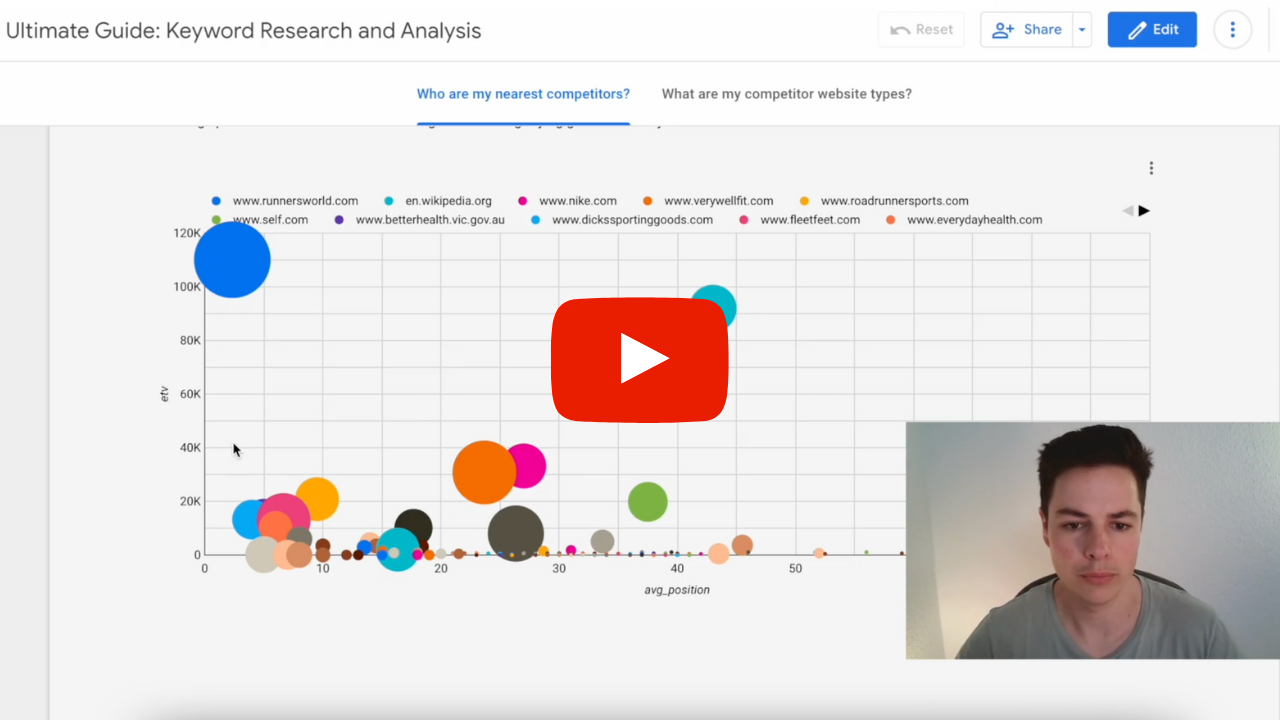
  </a>
</center>

Once you collected your data in Google sheets, you can copy the following dashboard on Looker Studio as a starting point for further analysis (link in the picture):

  <a href="https://lookerstudio.google.com/reporting/22410552-57f8-4eee-8050-596ab908ad5e" target="_blank">
  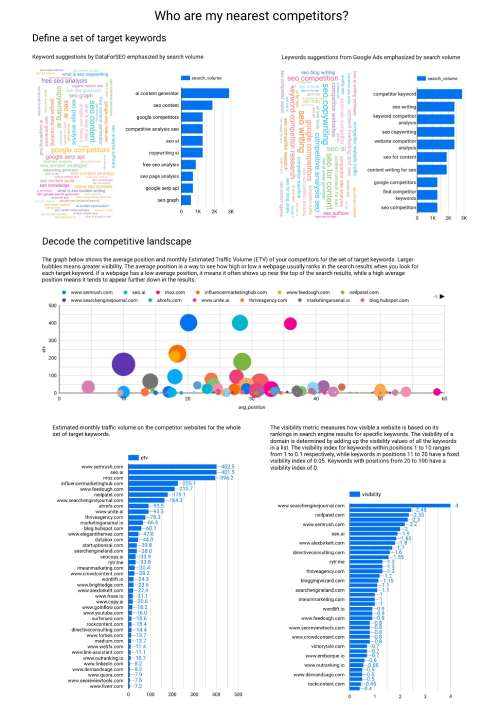
  </a>
</center>

<div class="markdown-google-sans">

## <strong>Getting started</strong>
</div>

The document that you are reading is not a static web page, but an interactive environment called a <strong>Colab notebook</strong> that lets you write and execute code.

For example, here is a <strong>code cell</strong> with a short Python script that computes a value, stores it in a variable and prints the result:

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut '**Shift/Ctrl+Enter**'. To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

The document that you're currently viewing isn't initially saved in your Drive, and any modifications you make won't be automatically saved. However, to create a personal copy, you can click on the "Copy to Drive" button shown in the image below. This will allow you to make changes to the code and access it at any time, since the copy will be saved to your own Google Drive account.

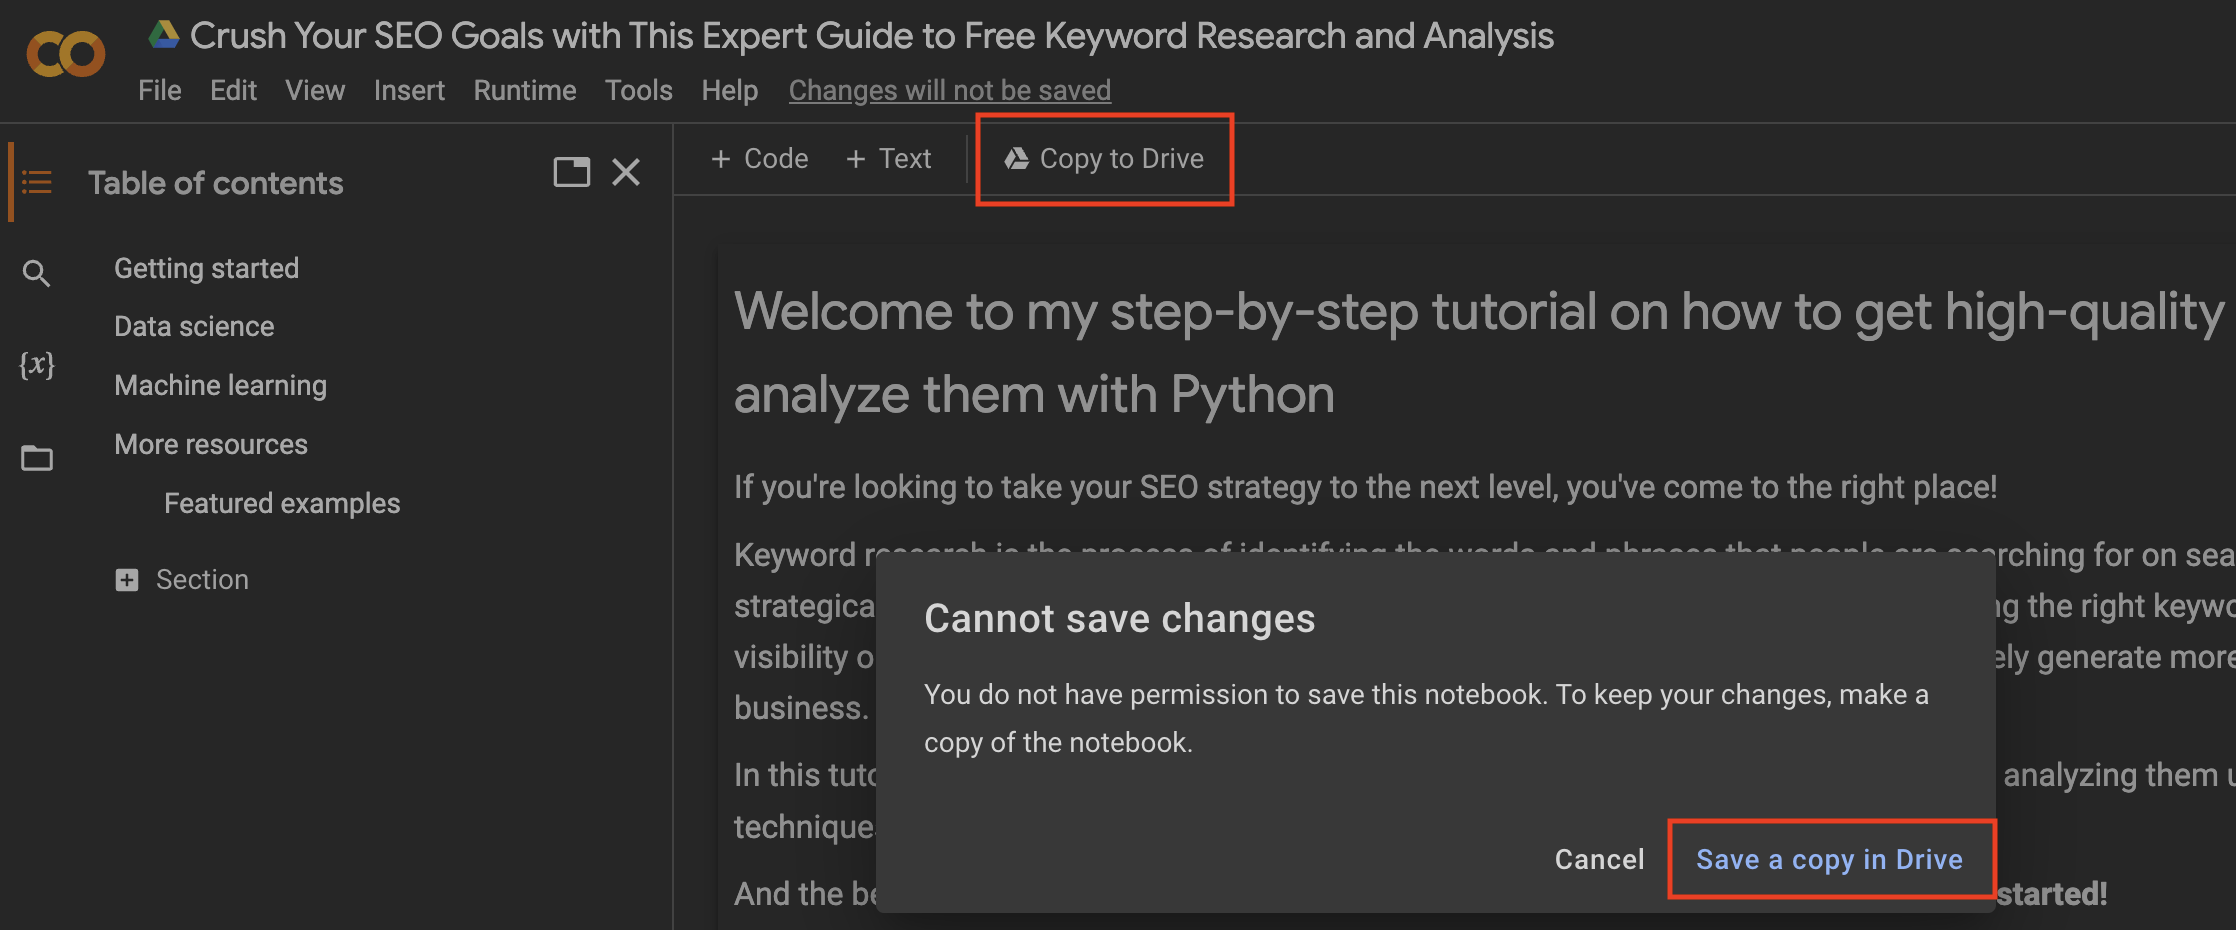

In case of problem, you can always start over and restart the notebook or delete its runtime into the "runtime" menu.

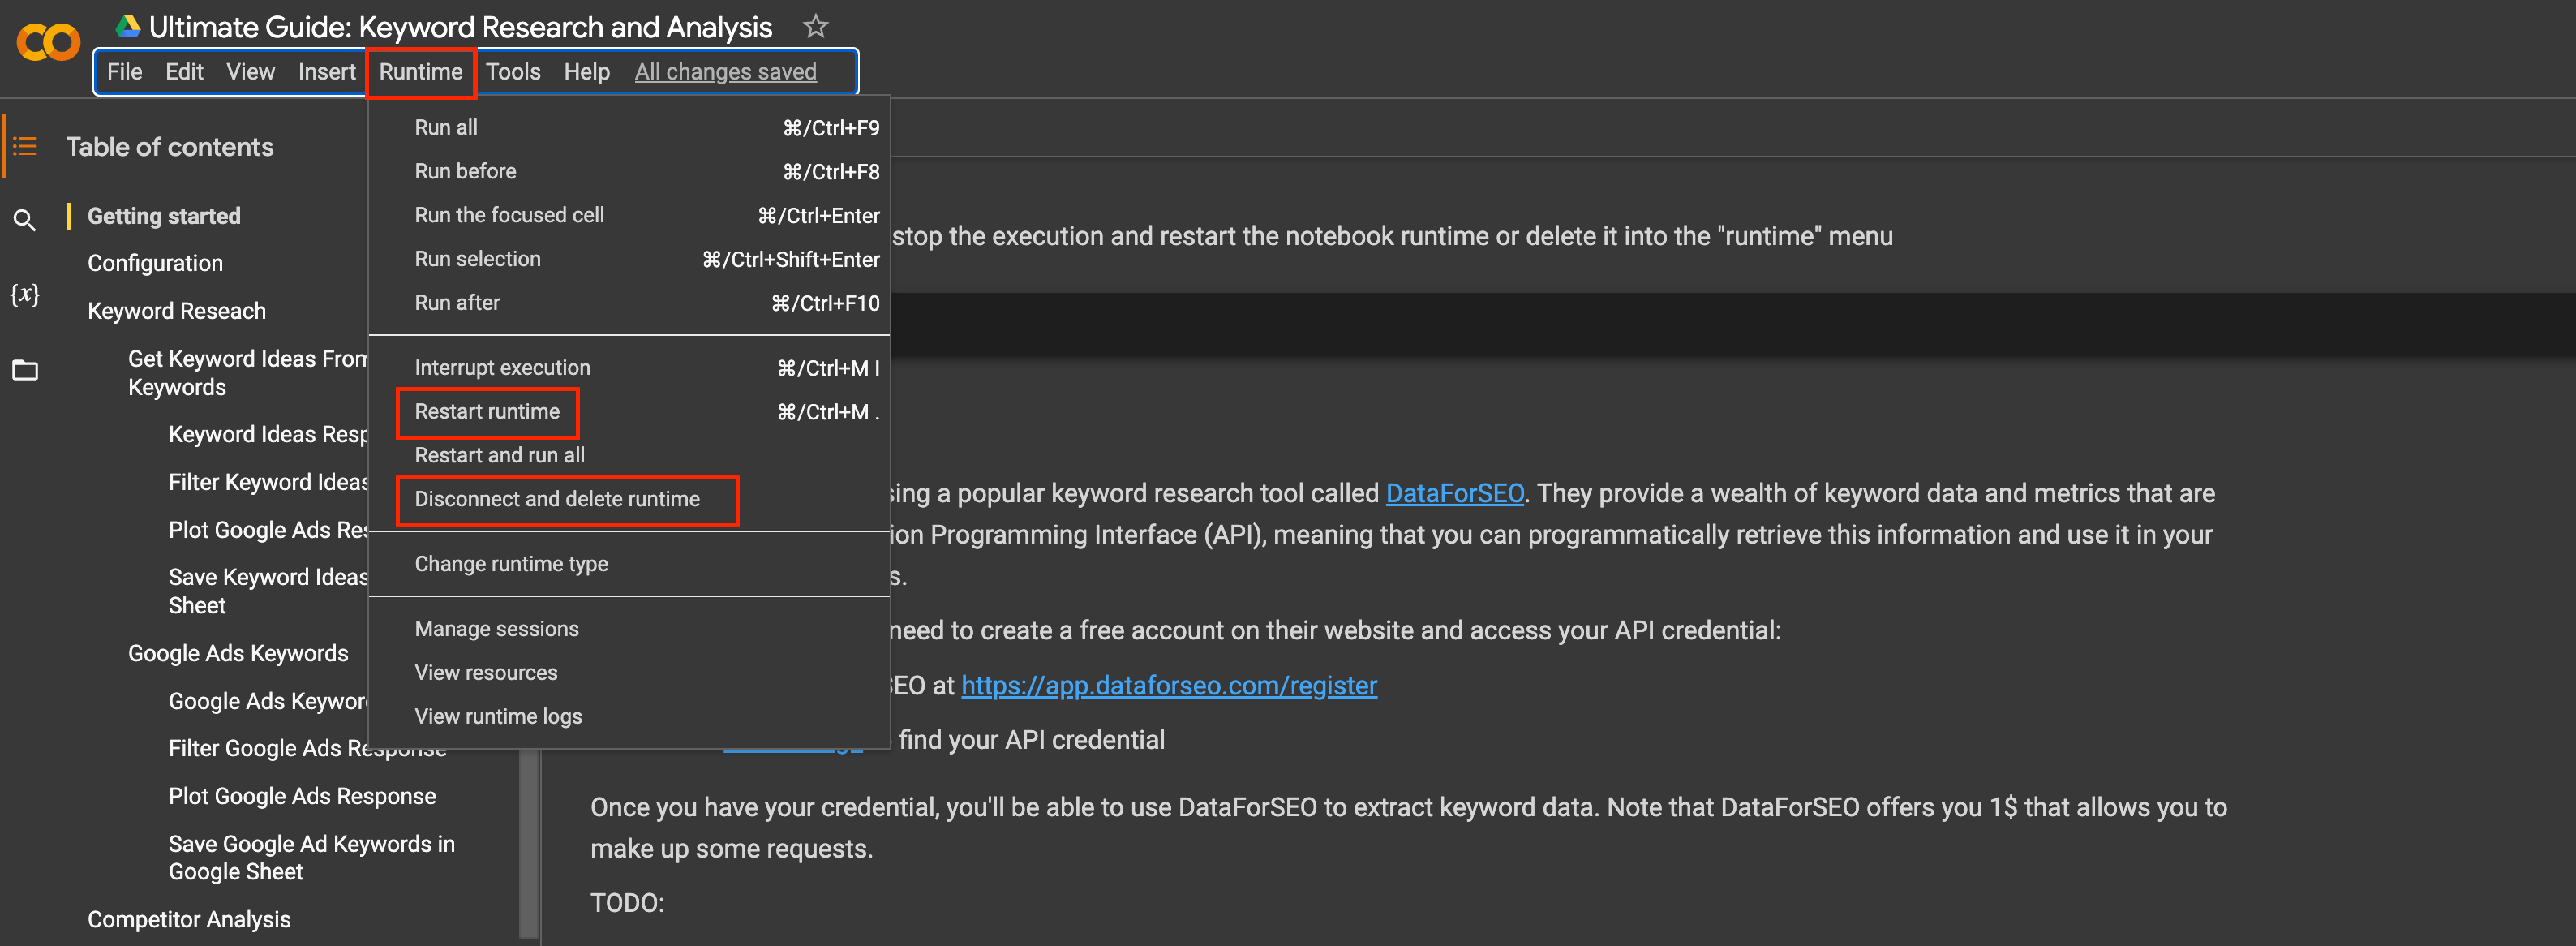

<div class="markdown-google-sans">

## Configuration
</div>

**DataForSEO API**

To use [DataForSEO](https://dataforseo.com/), you'll need to create a free account on their website and access your API credential:

1. Sign up for DataForSEO at [https://app.dataforseo.com/register](https://app.dataforseo.com/)

2. Go to [API settings](https://app.dataforseo.com/api-settings/api-access) to find your API credential

Once you have your credential, you'll be able to use DataForSEO to extract keyword data. Note that DataForSEO offers you 1$ that allows you to make up some requests.

**Google Cloud API**

To get a Google API key, you can follow these steps:

1. Go to the Google Cloud Console (https://console.cloud.google.com/).
2. Create or select a project.
3. In the sidebar, click on "APIs & Services" and then "Credentials".
4. Click "Create Credentials" and select "API Key".
5. Your API key will be displayed on the screen. You can copy it from here and use it in your code.

Get Google Cloud Project ID:

1. Open the Cloud Console: https://console.cloud.google.com/
2. Click on the project drop-down menu at the top of the page.
3. Select the project that contains the API key you want to use.
4. The project ID is displayed in the header of the Cloud Console dashboard, next to the project name.

**OpenAI API**

To obtain an OpenAI API key, follow these steps:

1. Sign up for OpenAI API: Visit the OpenAI website at https://www.openai.com/ and click on "Get started" or "Sign up" at the top right corner. Fill in the required information to create your account.

2. Log in to your OpenAI account: After signing up, log in to your account on the OpenAI website.

3. Access your API keys: Once you're logged in, click on your profile picture or avatar located at the top right corner of the page. In the drop-down menu, click on "Personal" to access your personal account settings.

4. View API keys: On your Personal settings page, find the "API keys" section. Click on the "View API keys" button to access your API keys. If you haven't generated an API key yet, you'll be able to create one here.

Specify the location where the data should be stored.

In [8]:
DRIVE_PATH = '/content/gdrive'
DATA_FOLDER_PATH = '/content/gdrive/MyDrive/SEOdata'
RESPONSE_FOLDER_PATH = '/content/gdrive/MyDrive/SEOdata/response'

Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount(DRIVE_PATH, force_remount=True)

Create the SEOdata and response folder in Google Drive

In [ ]:
import os
if not os.path.exists(DATA_FOLDER_PATH):
    print(f"Created the folder {DATA_FOLDER_PATH}")
    os.makedirs(DATA_FOLDER_PATH)
else:
  print(f"The folder '{DATA_FOLDER_PATH}' already exist")

In [ ]:
import os
if not os.path.exists(RESPONSE_FOLDER_PATH):
    print(f"Created the folder {RESPONSE_FOLDER_PATH}")
    os.makedirs(RESPONSE_FOLDER_PATH)
else:
  print(f"The folder '{RESPONSE_FOLDER_PATH}' already exist")

Get the Google Drive ID of the data folder

In [ ]:
!pip install xattr --quiet

from xattr import *
data_path_attr = xattr(DATA_FOLDER_PATH)
data_file_id = data_path_attr.get('user.drive.id')

DATA_FOLDER_ID = data_file_id.decode()
print(f'The data will be stored at: https://drive.google.com/drive/folders/{DATA_FOLDER_ID}')

Create an environment file to store API keys

In [ ]:
import os

env_path = os.path.join(DATA_FOLDER_PATH, "env")

if not os.path.exists(env_path):
    with open(env_path, "w") as f:
      f.write("DATAFORSEO_USERNAME=fake\n")
      f.write("DATAFORSEO_PASSWORD=fake\n")
      f.write("OPENAI_API_KEY=fake\n")
      f.write("GOOGLE_API_KEY=fake\n")
      f.write("GOOGLE_PROJECT_ID=fake\n")

    print(f"Created example env file at {env_path}")
else:
    print(f"env file already exists at {env_path}")

Load the keys from the env file

In [ ]:
!pip install python-dotenv --quiet
from dotenv import load_dotenv
import os

load_dotenv(env_path, override=True)
dataforseo_username = os.getenv("DATAFORSEO_USERNAME")
dataforseo_password = os.getenv("DATAFORSEO_PASSWORD")
openai_api_key = os.getenv("OPENAI_API_KEY")
google_api_key = os.getenv("GOOGLE_API_KEY")
google_project_id = os.getenv("GOOGLE_PROJECT_ID")

Create a Google sheet to store the dataframes

In [ ]:
!pip install -U gspread>=5.7.0 --quiet

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()

googlesheet_client = gspread.authorize(creds)

On the next cell, you will create a spreadsheet to store your data.
Once the spreadsheet is created, you can add the ID of the sheet by changing sheet_id = '1elvq.. (your sheet id)'.

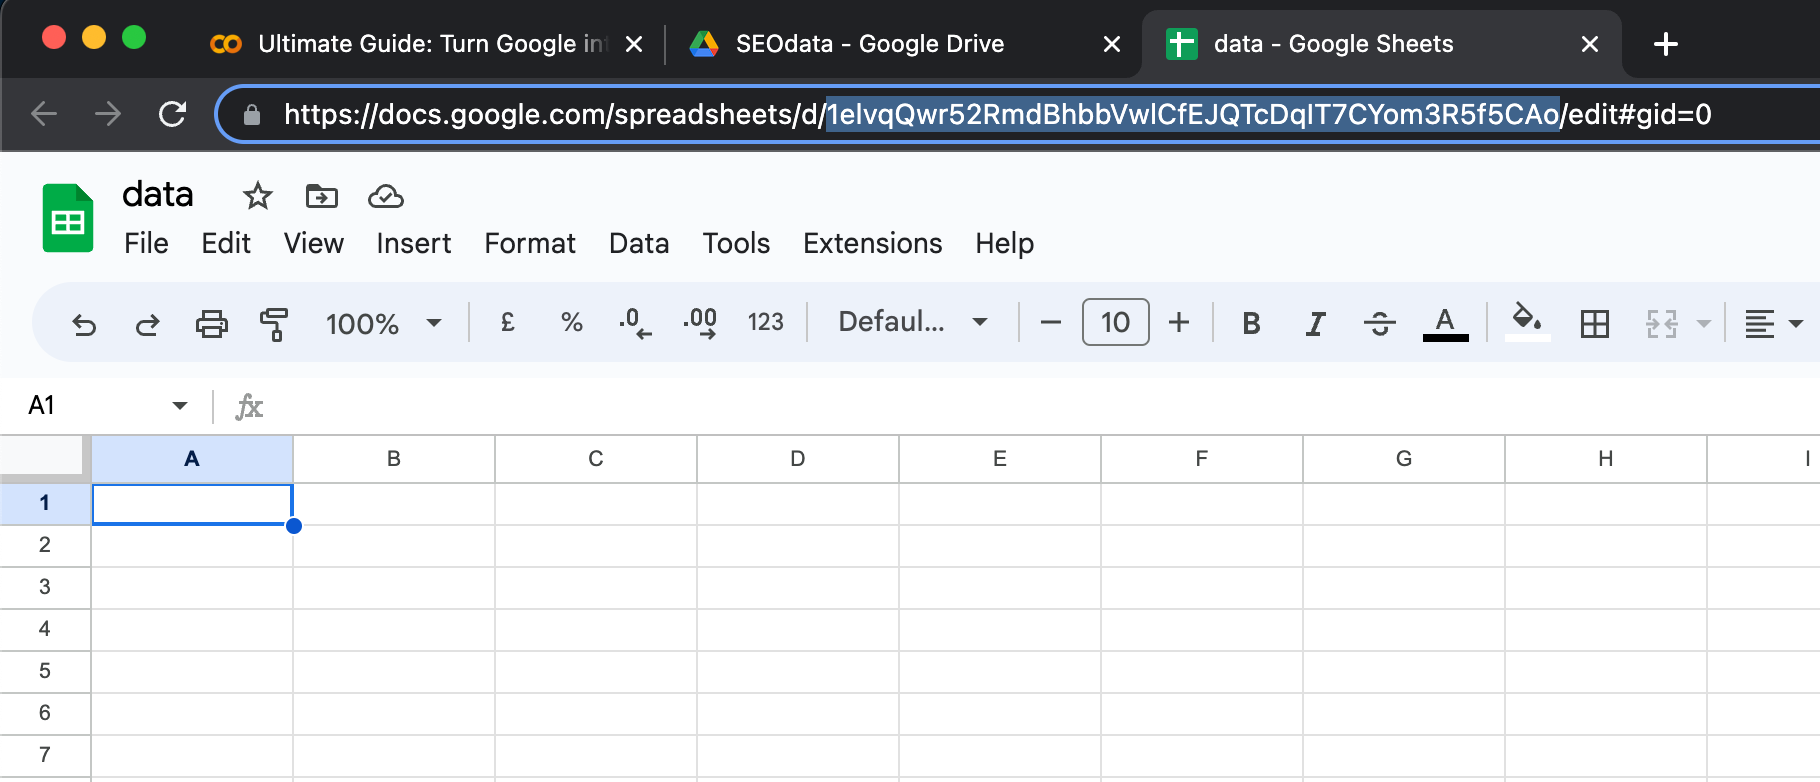

In [ ]:
# here you can set your spreadsheet ID (if you have one)
# For example: sheet_id='1VsOGn8gweoL-UNv1Qec33-A1lJ5ljsGuRQdKi70JXjs'
# Or you can let it as None and it will create a new spreadsheet called 'data'
sheet_id = None

if sheet_id is not None:
    # Open the sheet by ID
    spreadsheet = googlesheet_client.open_by_key(sheet_id)
    print(f"Opened spreadsheet: {spreadsheet.url}")
else:
    # Ask the user for the name of the sheet they want to create
    sheet_name = 'data'

    # Create a new sheet
    spreadsheet = googlesheet_client.create(sheet_name, folder_id=DATA_FOLDER_ID)
    print(f"Created spreadsheet: {spreadsheet.url}")

Create a client to fetch data from DataForSEO API

In [1]:
dataforseo_username = "admin@innovizeai.com"
dataforseo_password = "dee91d3c2f28b6b5"

In [2]:
from http.client import HTTPSConnection
from base64 import b64encode
from json import loads
from json import dumps

class RestClient:
    domain = "api.dataforseo.com"

    def __init__(self, username, password):
        self.username = username
        self.password = password

    def request(self, path, method, data=None):
        connection = HTTPSConnection(self.domain)
        try:
            base64_bytes = b64encode(
                ("%s:%s" % (self.username, self.password)).encode("ascii")
                ).decode("ascii")
            headers = {'Authorization' : 'Basic %s' %  base64_bytes, 'Content-Encoding' : 'gzip'}
            connection.request(method, path, headers=headers, body=data)
            response = connection.getresponse()
            return loads(response.read().decode())
        finally:
            connection.close()

    def get(self, path):
        return self.request(path, 'GET')

    def post(self, path, data):
        if isinstance(data, str):
            data_str = data
        else:
            data_str = dumps(data)
        return self.request(path, 'POST', data_str)

seodata_client = RestClient(dataforseo_username, dataforseo_password)

<div class="markdown-google-sans">

## Keyword Reseach
</div>

In [39]:
seed_keywords=[
    "AI solutions for businesses",
"Personalized AI services",
# "Workflow automation",
"AI consulting services",
"Business efficiency solutions",
"Operational excellence with AI",
"AI agents",
"Automation strategy development",
# "Performance evaluation in business",
# "Feasibility assessments for AI projects",
# "Tailored AI solutions",
# "Business process automation",
# "Insightful analytics for decision making",
# "ROI-focused AI implementation",
# "Expert AI guidance"
]

<div class="markdown-google-sans">

### Get Keyword Ideas From Seed Keywords
</div>

[This endpoint](https://docs.dataforseo.com/v3/dataforseo_labs/google/keyword_ideas/live/?python) finds relevant search terms related to your seed keywords. The algorithm selects keywords in the same categories as your seed keywords, providing up to 200 keyword ideas. Each keyword idea includes search volume, trends, CPC, competition, and impression/click data.

In [40]:
post_data_ki = dict()
post_data_ki[len(post_data_ki)] = dict(
    keywords= seed_keywords,
    location_name="United States",
    language_name="English",
    filters=[
        ["keyword_info.search_volume", ">", 10]
    ],
    include_serp_info=True,
    closely_variants=True,
    limit=200
)

In [79]:
post_data = dict()

post_data[len(post_data)] = dict(
    keyword="Ai agents",
    location_name="United States",
    language_name="English",
    include_serp_info=True,
    include_seed_keyword=True,
    limit=100
)

In [80]:
import json
import os
filename_ki = 'keyword_suggestions'
file_path = f'{filename_ki}.json'

if os.path.isfile(file_path):
  print('Loading existing file')
  with open(file_path, "r") as f:
    response_ki = json.load(f)
else:
  print('Get data from DataForSEO')
  response_ki = seodata_client.post(
      "/v3/dataforseo_labs/google/keyword_suggestions/live", post_data
  )

  if response_ki["status_code"] == 20000:
    with open(file_path, "w") as f:
      json.dump(response_ki, f)
  else:
    print(
        "error. Code: %d Message: %s"
            % (response_ki["status_code"], response_ki["status_message"])
        )

Get data from DataForSEO


<div class="markdown-google-sans">

#### Keyword Ideas Response
</div>

The cost of the request

In [81]:
response_ki['cost']

0.02

First item

In [82]:
results_ki = response_ki['tasks'][0]["result"][0]['items']
results_ki[0]['keyword']

'agents in ai'

In [83]:
results_ki[0]['keyword_info']

{'se_type': 'google',
 'last_updated_time': '2024-10-10 15:09:19 +00:00',
 'competition': 0.43,
 'competition_level': 'MEDIUM',
 'cpc': 53.49,
 'search_volume': 12100,
 'low_top_of_page_bid': 5.76,
 'high_top_of_page_bid': 148.27,
 'categories': [10003,
  10011,
  10012,
  10042,
  10089,
  10102,
  10550,
  11772,
  11854,
  12930],
 'monthly_searches': [{'year': 2024, 'month': 9, 'search_volume': 22200},
  {'year': 2024, 'month': 8, 'search_volume': 14800},
  {'year': 2024, 'month': 7, 'search_volume': 14800},
  {'year': 2024, 'month': 6, 'search_volume': 14800},
  {'year': 2024, 'month': 5, 'search_volume': 14800},
  {'year': 2024, 'month': 4, 'search_volume': 18100},
  {'year': 2024, 'month': 3, 'search_volume': 12100},
  {'year': 2024, 'month': 2, 'search_volume': 9900},
  {'year': 2024, 'month': 1, 'search_volume': 9900},
  {'year': 2023, 'month': 12, 'search_volume': 6600},
  {'year': 2023, 'month': 11, 'search_volume': 8100},
  {'year': 2023, 'month': 10, 'search_volume': 6600}

In [47]:
results_ki[0]['keyword_properties']

{'se_type': 'google',
 'core_keyword': None,
 'synonym_clustering_algorithm': 'text_processing',
 'keyword_difficulty': 21,
 'detected_language': 'en',
 'is_another_language': False}

In [48]:
results_ki[0]['impressions_info']

{'se_type': 'google',
 'last_updated_time': '2022-04-12 10:06:35 +00:00',
 'bid': 999,
 'match_type': 'exact',
 'ad_position_min': 3.21,
 'ad_position_max': 3,
 'ad_position_average': 2.92,
 'cpc_min': 474.78,
 'cpc_max': 580.28,
 'cpc_average': 527.53,
 'daily_impressions_min': 3.51,
 'daily_impressions_max': 4.29,
 'daily_impressions_average': 3.9,
 'daily_clicks_min': 0.11,
 'daily_clicks_max': 0.14,
 'daily_clicks_average': 0.12,
 'daily_cost_min': 58.62,
 'daily_cost_max': 71.65,
 'daily_cost_average': 65.13}

In [84]:
results_ki[0]['serp_info']

{'se_type': 'google',
 'check_url': 'https://www.google.com/search?q=agents%20in%20ai&num=100&hl=en&gl=US&gws_rd=cr&ie=UTF-8&oe=UTF-8&glp=1&uule=w+CAIQIFISCQs2MuSEtepUEUK33kOSuTsc',
 'serp_item_types': ['featured_snippet',
  'people_also_ask',
  'organic',
  'related_searches'],
 'se_results_count': 536000000,
 'last_updated_time': '2024-09-15 03:06:30 +00:00',
 'previous_updated_time': '2024-08-04 15:14:46 +00:00'}

Backlink data provides the average number of backlinks, referring pages and domains, as well as the average rank values among the top-10 websites ranking organically for the keyword

In [85]:
results_ki[0]['avg_backlinks_info']

{'se_type': 'google',
 'backlinks': 94,
 'dofollow': 52.2,
 'referring_pages': 82.1,
 'referring_domains': 47.7,
 'referring_main_domains': 46.1,
 'rank': 142.3,
 'main_domain_rank': 629.4,
 'last_updated_time': '2024-09-15 03:06:30 +00:00'}

In [86]:
results_ki[0]['search_intent_info']

{'se_type': 'google',
 'main_intent': 'navigational',
 'foreign_intent': None,
 'last_updated_time': '2023-03-04 12:15:03 +00:00'}

In [87]:
results_ki

[{'se_type': 'google',
  'keyword': 'agents in ai',
  'location_code': 2840,
  'language_code': 'en',
  'keyword_info': {'se_type': 'google',
   'last_updated_time': '2024-10-10 15:09:19 +00:00',
   'competition': 0.43,
   'competition_level': 'MEDIUM',
   'cpc': 53.49,
   'search_volume': 12100,
   'low_top_of_page_bid': 5.76,
   'high_top_of_page_bid': 148.27,
   'categories': [10003,
    10011,
    10012,
    10042,
    10089,
    10102,
    10550,
    11772,
    11854,
    12930],
   'monthly_searches': [{'year': 2024, 'month': 9, 'search_volume': 22200},
    {'year': 2024, 'month': 8, 'search_volume': 14800},
    {'year': 2024, 'month': 7, 'search_volume': 14800},
    {'year': 2024, 'month': 6, 'search_volume': 14800},
    {'year': 2024, 'month': 5, 'search_volume': 14800},
    {'year': 2024, 'month': 4, 'search_volume': 18100},
    {'year': 2024, 'month': 3, 'search_volume': 12100},
    {'year': 2024, 'month': 2, 'search_volume': 9900},
    {'year': 2024, 'month': 1, 'search_volu

Number of keywords in the response

In [88]:
import pandas as pd

words = []
cpc = []
search_volume = []
low_top_of_page_bid = []
high_top_of_page_bid = []
competition = []
competition_level = []
keyword_difficulty = []
keyword_difficulty = []
for result in results_ki:
    words.append(result['keyword'])
    cpc.append(result["keyword_info"]["cpc"])
    search_volume.append(result["keyword_info"]['search_volume'])
    low_top_of_page_bid.append(result["keyword_info"]["low_top_of_page_bid"])
    high_top_of_page_bid.append(result["keyword_info"]["high_top_of_page_bid"])
    competition.append(result["keyword_info"]["competition"])
    competition_level.append(result["keyword_info"]["competition_level"])
    keyword_difficulty.append(result["keyword_properties"]["keyword_difficulty"])

df_ki = pd.DataFrame(
    {
        "keywords": words,
        "cpc": cpc,
        "search_volume": search_volume,
        "low_top_of_page_bid": low_top_of_page_bid,
        "high_top_of_page_bid": high_top_of_page_bid,
        "competition": competition,
        "competition_level": competition_level,
        "keyword_difficulty": keyword_difficulty
    }
)

In [89]:
df_ki

,keywords,cpc,search_volume,low_top_of_page_bid,high_top_of_page_bid,competition,competition_level,keyword_difficulty
0,agents in ai,53.49,12100,5.76,148.27,0.43,MEDIUM,30.0
1,agents ai,53.49,12100,5.76,148.27,0.43,MEDIUM,30.0
2,intelligent agents in ai,53.49,12100,5.76,148.27,0.43,MEDIUM,23.0
3,intelligent agents ai,53.49,12100,5.76,148.27,0.43,MEDIUM,23.0
4,ai intelligent agents,53.49,12100,5.76,148.27,0.43,MEDIUM,31.0
...,...,...,...,...,...,...,...,...
95,how do ai agents work,11.39,40,2.56,20.00,0.14,LOW,22.0
96,best ai for insurance agents,25.78,40,9.52,32.12,0.28,LOW,0.0
97,ai agents startups,8.66,40,5.25,17.47,0.49,MEDIUM,8.0
98,ai types of agents,154.60,30,138.71,206.84,0.08,LOW,1.0


Get the number of keywords

In [90]:
print('Number of keywords: ', len(df_ki))

Number of keywords:  100


<div class="markdown-google-sans">

#### Filter Keyword Ideas Response
</div>

Find keywords with high search volume and low competition level

In [102]:
df_ki.query("competition_level == 'LOW'").sort_values(by="search_volume", ascending=False).head(5)

,keywords,cpc,search_volume,low_top_of_page_bid,high_top_of_page_bid,competition,competition_level,keyword_difficulty
6,ai travel agents,3.53,880,0.62,5.66,0.26,LOW,39.0
8,what are ai agents,67.04,590,10.09,173.62,0.23,LOW,45.0
9,ai agents examples,47.41,480,3.33,163.66,0.32,LOW,9.0
13,what is ai agents,76.07,320,10.09,204.55,0.23,LOW,46.0
18,google ai agents,12.22,260,2.82,95.00,0.13,LOW,40.0


Find keywords with low difficulty, low competition level, and high CPC

In [106]:
df_ki.query("competition_level == 'LOW' & keyword_difficulty < 50 & search_volume>500").sort_values(by="search_volume", ascending=False).head(20)

,keywords,cpc,search_volume,low_top_of_page_bid,high_top_of_page_bid,competition,competition_level,keyword_difficulty
6,ai travel agents,3.53,880,0.62,5.66,0.26,LOW,39.0
8,what are ai agents,67.04,590,10.09,173.62,0.23,LOW,45.0


In [111]:
# print the list of keywords to make it easier to copy
analyze_keywords= df_ki.query("competition_level == 'LOW' & keyword_difficulty < 50").sort_values(by="search_volume", ascending=False).head(20)['keywords'].to_list()

In [121]:
analyze_keywords

['ai travel agents',
 'what are ai agents',
 'ai agents examples',
 'what is ai agents',
 'google ai agents',
 'ai agents platform',
 'multi agents ai',
 'ai agents architecture',
 'ai for insurance agents',
 'aws gen ai agents',
 'will ai replace real estate agents',
 'ai agents definition',
 'microsoft ai agents',
 'will real estate agents be replaced by ai',
 'ai agents reddit',
 'crew ai agents',
 'vertex ai agents',
 'langchain ai agents',
 'what are agents in ai',
 'ai agents that matter']

Results with CPC information

In [122]:
df_ki.query("competition_level == 'LOW' & keyword_difficulty < 50").sort_values(by="search_volume", ascending=False).head(20)

,keywords,cpc,search_volume,low_top_of_page_bid,high_top_of_page_bid,competition,competition_level,keyword_difficulty
6,ai travel agents,3.53,880,0.62,5.66,0.26,LOW,39.0
8,what are ai agents,67.04,590,10.09,173.62,0.23,LOW,45.0
9,ai agents examples,47.41,480,3.33,163.66,0.32,LOW,9.0
13,what is ai agents,76.07,320,10.09,204.55,0.23,LOW,46.0
18,google ai agents,12.22,260,2.82,95.00,0.13,LOW,40.0
21,ai agents platform,80.39,210,7.95,100.53,0.26,LOW,27.0
22,multi agents ai,34.73,170,2.80,90.00,0.21,LOW,22.0
23,ai agents architecture,6.45,170,2.80,15.30,0.33,LOW,4.0
25,ai for insurance agents,24.01,170,6.51,18.85,0.23,LOW,0.0
29,aws gen ai agents,6.14,140,NaN,NaN,0.17,LOW,36.0


Define a set of keywords and check their properties

<div class="markdown-google-sans">

#### Plot Google Ads Response
</div>

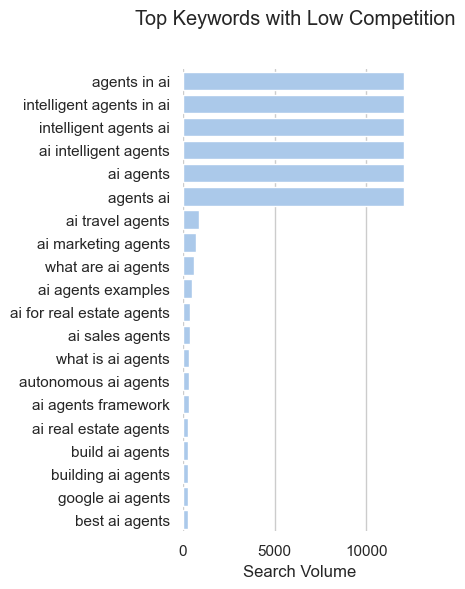

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(3, 6))

f.suptitle("Top Keywords with Low Competition")
sns.set_color_codes("pastel")

top_keywords_ki = df_ki.sort_values(by="search_volume", ascending=False).head(20)
sns.barplot(x="search_volume", y="keywords", data=top_keywords_ki,
            label="search_volume", color="b")

ax.legend(ncol=2, loc="lower right", frameon=True)
ax.set(ylabel="",
       xlabel="Search Volume")

plt.legend([],[], frameon=False)
sns.despine(left=True, bottom=True)

<div class="markdown-google-sans">

#### Save Keyword Ideas in Google Sheet
</div>

Create a worksheet in the spreadsheet

In [ ]:
worksheets = [sheet.title for sheet in spreadsheet.worksheets()]
if not filename_ki in worksheets:
  print("Create a new worksheet")
  worksheet_ki = spreadsheet.add_worksheet(title=filename_ki, rows=100, cols=20)
else:
  print("Attach to existing worksheet")
  worksheet_ki = spreadsheet.worksheet(title=filename_ki)

Store the dataframe in the worksheet

In [ ]:
worksheet_ki.clear()

In [ ]:
worksheet_ki.update([df_ki.columns.values.tolist()] + df_ki.fillna('').values.tolist())



<div class="markdown-google-sans">

### Google Ads Keywords for Keywords
</div>

[This endpoint](https://docs.dataforseo.com/v3/keywords_data/google_ads/keywords_for_keywords/task_post/?python) provides relevant keywords for the specified keywords. Set up to 20 keywords in the keywords array and get keyword suggestions from Google Ad.

In [38]:
post_data_ga = dict()
post_data_ga[len(post_data_ga)] = dict(
    location_name="United States",
    keywords=[
       "AI solutions for businesses",
"Workflow automation",
"AI consulting services",
"Personalized AI agents",
"Business process automation",
"Operational efficiency"
    ],
)

In [ ]:
import json

filename_ga = 'keywords_for_keywords'
file_path = f'{filename_ga}.json'

if os.path.isfile(file_path):
  print('Loading existing file')
  with open(file_path, "r") as f:
    response_ga = json.load(f)
else:
  print('Get data from DataForSEO')
  response_ga = seodata_client.post(
      "/v3/keywords_data/google_ads/keywords_for_keywords/live", post_data_ga
  )

  if response_ga["status_code"] == 20000:
    with open(file_path, "w") as f:
      json.dump(response_ga, f)
  else:
    print(
        "error. Code: %d Message: %s"
            % (response_ga["status_code"], response_ga["status_message"])
        )

If there were no errors, you should be able to see some data in the response variable

<div class="markdown-google-sans">

#### Google Ads Keyword Response
</div>


The cost of the request in USD

In [ ]:
response_ga['cost']

The first result

In [ ]:
results_ga = response_ga["tasks"][0]["result"]
results_ga[0]

Store the result in a dataframe

In [42]:
import pandas as pd

words = []
search_volume = []
low_top_of_page_bid = []
high_top_of_page_bid = []
competition = []
competition_index = []
for result in results_ga:
    words.append(result["keyword"])
    search_volume.append(result["search_volume"])
    low_top_of_page_bid.append(result["low_top_of_page_bid"])
    high_top_of_page_bid.append(result["high_top_of_page_bid"])
    competition.append(result["competition"])
    competition_index.append(result["competition_index"])

df_ga = pd.DataFrame(
    {
        "keywords": words,
        "search_volume": search_volume,
        "low_top_of_page_bid": low_top_of_page_bid,
        "high_top_of_page_bid": high_top_of_page_bid,
        "competition": competition,
        "competition_index": competition_index,
    }
)

Get the number of keywords

In [96]:
print('Number of keywords: ', len(df_ga))

NameError: name 'df_ga' is not defined

<div class="markdown-google-sans">

#### Filter Google Ads Response
</div>

**low_top_of_page_bid**

minimum bid for the ad to be displayed at the top of the first page indicates the value greater than about 20% of the lowest bids for which ads were displayed (based on Google Ads statistics for advertisers)


**high_top_of_page_bid**

maximum bid for the ad to be displayed at the top of the first page
indicates the value greater than about 80% of the lowest bids for which ads were displayed (based on Google Ads statistics for advertisers)



In [ ]:
df_ga.query("competition == 'LOW'").sort_values(by="search_volume", ascending=False)

Only results with bid information

In [ ]:
df_ga.query("competition == 'LOW' & low_top_of_page_bid == low_top_of_page_bid").sort_values(by="high_top_of_page_bid", ascending=False).head(10)

<div class="markdown-google-sans">

#### Plot Google Ads Response
</div>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(3, 6))

f.suptitle("Top Keywords with Low Competition")
sns.set_color_codes("pastel")
sns.barplot(x="search_volume", y="keywords",
            data=df_ga.query("competition == 'LOW'").sort_values(by="search_volume", ascending=False).head(20),
            label="search_volume", color="b")

ax.legend(ncol=2, loc="lower right", frameon=True)
ax.set(ylabel="",
       xlabel="Search Volume")

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))
plt.legend([],[], frameon=False)
sns.despine(left=True, bottom=True)

<div class="markdown-google-sans">

#### Save Google Ad Keywords in Google Sheet
</div>

Create a worksheet in the spreadsheet

In [ ]:
worksheets = [sheet.title for sheet in spreadsheet.worksheets()]
if not filename_ga in worksheets:
  print("Create a new worksheet")
  worksheet_ga = spreadsheet.add_worksheet(title=filename_ga, rows=100, cols=20)
else:
  print("Attach to existing worksheet")
  worksheet_ga = spreadsheet.worksheet(title=filename_ga)

Store the dataframe in the worksheet

In [ ]:
worksheet_ga.clear()

In [ ]:
worksheet_ga.update([df_ga.columns.values.tolist()] + df_ga.fillna('').values.tolist())

<div class="markdown-google-sans">

## Competitor Analysis
</div>


<div class="markdown-google-sans">

### Identify Your Competitors
</div>

[This endpoint](https://docs.dataforseo.com/v3/dataforseo_labs/google/serp_competitors/live/?python) offers a list of domains ranking for specified keywords, along with their SERP rankings, ratings, estimated traffic volume, and visibility values.

Define up to 200 keywords

In [112]:
post_data_serp = dict()
post_data_serp[len(post_data_serp)] = dict(
    keywords= analyze_keywords,
    location_name="United States",
    language_name="English",
    filters=[
        ["relevant_serp_items", ">", 0],
        "or",
        ["median_position", "in", [ 1, 10 ]]
    ]
)

In [123]:
import json

filename_serp = 'serp_competitors'
file_path = f'{filename_serp}.json'

if os.path.isfile(file_path):
  print('Loading existing file')
  with open(file_path, "r") as f:
    response_serp = json.load(f)
else:
  print('Get data from DataForSEO')
  response_serp = seodata_client.post(
      "/v3/dataforseo_labs/google/serp_competitors/live", post_data_serp
  )

  if response_serp["status_code"] == 20000:
    with open(file_path, "w") as f:
      json.dump(response_serp, f)
  else:
    print(
        "error. Code: %d Message: %s"
            % (response_serp["status_code"], response_serp["status_message"])
        )

Loading existing file


<div class="markdown-google-sans">

#### SERP Competitor Response
</div>

Cost in USD

In [115]:
response_serp['cost']

0.02

First result

In [116]:
results_serp = response_serp['tasks'][0]['result'][0]['items']
results_serp[0]

{'se_type': 'google',
 'domain': 'www.youtube.com',
 'avg_position': 10.823529411764707,
 'median_position': 8,
 'rating': 1516,
 'etv': 85.840502,
 'keywords_count': 17,
 'visibility': 5.349999999999999,
 'relevant_serp_items': 17,
 'keywords_positions': {'what is ai agents': [4],
  'what are ai agents': [4],
  'multi agents ai': [8],
  'google ai agents': [9],
  'aws gen ai agents': [9],
  'ai travel agents': [21],
  'ai agents platform': [38],
  'ai agents architecture': [4],
  'will real estate agents be replaced by ai': [8],
  'will ai replace real estate agents': [14],
  'what are agents in ai': [8],
  'vertex ai agents': [4],
  'microsoft ai agents': [9],
  'langchain ai agents': [14],
  'crew ai agents': [5],
  'ai agents that matter': [8],
  'ai agents definition': [17]}}

In [118]:
import pandas as pd

domain = []
avg_position = []
median_position = []
rating = []
etv = []
keywords_count = []
visibility = []

for result in results_serp:
    domain.append(result['domain'])
    avg_position.append(result['avg_position'])
    median_position.append(result['median_position'])
    rating.append(result['rating'])
    etv.append(result['etv'])
    keywords_count.append(result['keywords_count'])
    visibility.append(result['visibility'])

df_serp = pd.DataFrame(
    {
        "domain": domain,
        "avg_position": avg_position,
        "median_position": median_position,
        "rating": rating,
        "etv": etv,
        "keywords_count": keywords_count,
        "visibility": visibility,
    }
)

Get the number of items

In [119]:
print('Number of items: ', len(df_serp))

Number of items:  100


Show the dataframe

In [124]:
df_serp.head(5)

,domain,avg_position,median_position,rating,etv,keywords_count,visibility
0,www.youtube.com,10.823529,8,1516,85.840502,17,5.35
1,medium.com,21.642857,11,1097,46.612470,14,2.75
2,www.linkedin.com,39.166667,30,1095,16.065460,18,1.55
3,www.salesforce.com,15.000000,6,1020,106.946890,10,5.40
4,www.reddit.com,18.583333,10,977,92.713180,12,4.05


<div class="markdown-google-sans">

#### Sort SERP Competitor Response
</div>

In [125]:
df_serp.sort_values(by="median_position", ascending=True).head(5)

,domain,avg_position,median_position,rating,etv,keywords_count,visibility
6,aws.amazon.com,10.888889,1,802,397.07660,9,6.90
13,www.servicenow.com,22.375000,1,621,123.44952,6,4.90
77,nowbam.com,2.500000,2,195,25.28300,2,1.70
78,www.washingtonian.com,2.500000,2,195,26.57700,2,1.70
38,amelia.ai,18.500000,4,326,57.59650,4,1.45


<div class="markdown-google-sans">

#### Plot SERP Competitors
</div>

In [126]:
top_competitors = df_serp.sort_values('visibility', ascending=False).head(10)
top_competitors['main_domain'] = top_competitors['domain'].apply(lambda row: row if row[:4] != 'www.' else row[4:])

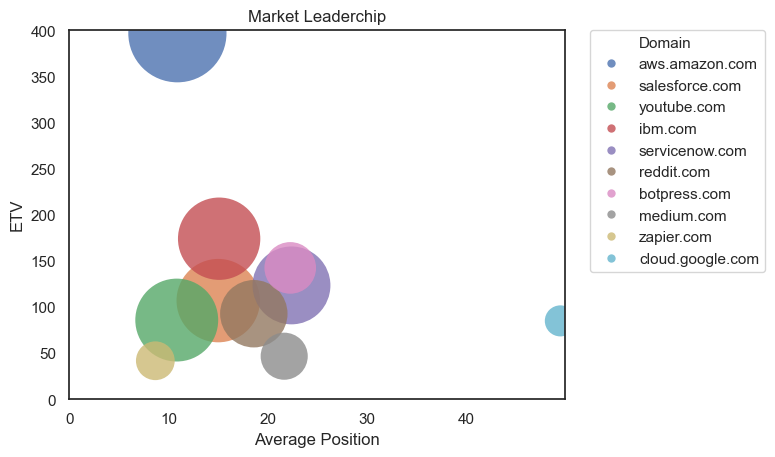

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

sns.set_style('white')
ax = sns.scatterplot(x="avg_position", y="etv", hue="domain", size="visibility", data=top_competitors, sizes=(500, 5_000),
                     palette='deep', edgecolor='none', alpha=0.8)

handles, labels = ax.get_legend_handles_labels()
legend_labels = ['Domain']

for domain in top_competitors['main_domain']:
    legend_labels.append(domain)

plt.legend(handles=handles, labels=legend_labels, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

max_etv =  top_competitors['etv'].max()
max_avg_position = top_competitors['avg_position'].max()

ax.set_title("Market Leaderchip")
ax.set_xlabel("Average Position")
ax.set_ylabel("ETV")
ax.set_xlim([0, max_avg_position + max_avg_position * 0.01])
ax.set_ylim([0, max_etv + max_etv * 0.01])

plt.show()

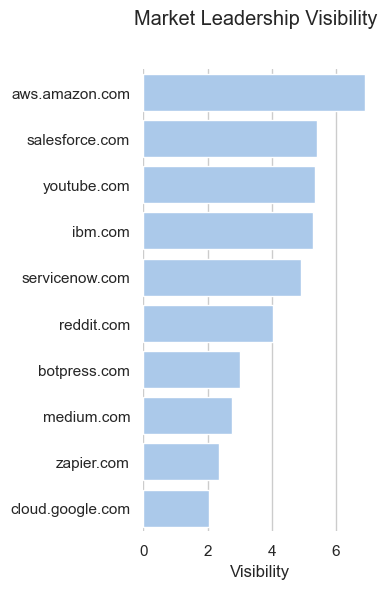

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(3, 6))

f.suptitle("Market Leadership Visibility")

sns.set_color_codes("pastel")
sns.barplot(x="visibility", y="main_domain", data=top_competitors, color="b")

ax.set(ylabel="",
       xlabel="Visibility")

plt.legend([],[], frameon=False)
sns.despine(left=True, bottom=True)

<div class="markdown-google-sans">

#### Save SERP Competitors in Google Sheet
</div>

Create a worksheet in the spreadsheet

In [ ]:
worksheets = [sheet.title for sheet in spreadsheet.worksheets()]
if not filename_serp in worksheets:
  print("Create a new worksheet")
  worksheet_serp = spreadsheet.add_worksheet(title=filename_serp, rows=100, cols=20)
else:
  print("Attach to existing worksheet")
  worksheet_serp = spreadsheet.worksheet(title=filename_serp)

Store the dataframe in the worksheet

In [ ]:
worksheet_serp.clear()

In [ ]:
worksheet_serp.update([df_serp.columns.values.tolist()] + df_serp.fillna('').values.tolist())

### Discover your competitors’ ranking keywords
</div>

By using [this endpoint](https://docs.dataforseo.com/v3/dataforseo_labs/google/ranked_keywords/live/?python) you can obtain a list of keywords that a given domain or webpage is currently ranking for. Additionally, you will receive information on the SERP elements associated with the keyword's position, including impressions, monthly searches, and other pertinent data.

In [129]:
post_data_ck = dict()
post_data_ck[len(post_data_ck)] = dict(
    target="aws.amazon.com",
    location_name="United States",
    language_name="English",
    filters=[
        ["keyword_data.keyword_info.search_volume", ">", 10],
        "and",
        [
            ["ranked_serp_element.serp_item.type", "<>", "paid"],
            "or",
            ["ranked_serp_element.serp_item.is_paid", "=", False]
        ]
    ],
    limit=50
)

In [130]:
import json

filename_ck = "ranked_keywords"
# os.makedirs(RESPONSE_FOLDER_PATH, exist_ok=True)
file_path = f'{filename_ck}.json'


if os.path.isfile(file_path):
  print('Loading existing file')
  with open(file_path, "r") as f:
    response_ck = json.load(f)
else:
  print('Get data from DataForSEO')
  response_ck = seodata_client.post(
      "/v3/dataforseo_labs/google/ranked_keywords/live", post_data_ck
  )

  if response_ck["status_code"] == 20000:
    with open(file_path, "w") as f:
      json.dump(response_ck, f)
  else:
    print(
        "error. Code: %d Message: %s"
            % (response_ck["status_code"], response_ck["status_message"])
        )

Get data from DataForSEO


<div class="markdown-google-sans">

#### Competitor Keywords Response
</div>

In [131]:
response_ck['cost']

0.015

Store keywords in dataframe

In [132]:
items_ck = response_ck["tasks"][0]["result"][0]['items']

data_ck = {
    "keyword": [],
    "competition": [],
    "competition_level": [],
    "cpc": [],
    "search_volume": [],
    "low_top_of_page_bid": [],
    "high_top_of_page_bid": [],
    "se_results_count": [],
    "main_intent": [],
    "rank_group": [],
    "rank_absolute": [],
    "position": [],
    "title": [],
    "description": [],
    "main_domain": [],
    "etv": [],
    "impressions_etv": [],
    "is_new": [],
    "is_up": [],
    "is_down": [],
}

In [133]:
for item in items_ck:
    data_ck["keyword"].append(item['keyword_data']['keyword'])
    data_ck["competition"].append(item['keyword_data']['keyword_info']['competition'])
    data_ck["competition_level"].append(item['keyword_data']['keyword_info']['competition_level'])
    data_ck["cpc"].append(item['keyword_data']['keyword_info']['cpc'])
    data_ck["search_volume"].append(item['keyword_data']['keyword_info']['search_volume'])
    data_ck["low_top_of_page_bid"].append(item['keyword_data']['keyword_info']['low_top_of_page_bid'])
    data_ck["high_top_of_page_bid"].append(item['keyword_data']['keyword_info']['high_top_of_page_bid'])
    data_ck["se_results_count"].append(item['keyword_data']['serp_info']['se_results_count'])
    data_ck["main_intent"].append(item['keyword_data']['search_intent_info']['main_intent'])
    data_ck["rank_group"].append(item['ranked_serp_element']['serp_item']['rank_group'])
    data_ck["rank_absolute"].append(item['ranked_serp_element']['serp_item']['rank_absolute'])
    data_ck["position"].append(item['ranked_serp_element']['serp_item']['position'])
    data_ck["title"].append(item['ranked_serp_element']['serp_item']['title'])
    data_ck["description"].append(item['ranked_serp_element']['serp_item']['description'])
    data_ck["main_domain"].append(item['ranked_serp_element']['serp_item']['main_domain'])
    data_ck["etv"].append(item['ranked_serp_element']['serp_item']['etv'])
    data_ck["impressions_etv"].append(item['ranked_serp_element']['serp_item']['impressions_etv'])
    data_ck["is_new"].append(item['ranked_serp_element']['serp_item']['rank_changes']['is_new'])
    data_ck["is_up"].append(item['ranked_serp_element']['serp_item']['rank_changes']['is_up'])
    data_ck["is_down"].append(item['ranked_serp_element']['serp_item']['rank_changes']['is_down'])

In [134]:
import pandas as pd
df_ck = pd.DataFrame(data_ck)

In [135]:
df_ck

,keyword,competition,competition_level,cpc,search_volume,low_top_of_page_bid,high_top_of_page_bid,se_results_count,main_intent,rank_group,rank_absolute,position,title,description,main_domain,etv,impressions_etv,is_new,is_up,is_down
0,1 what is smtp,NaN,LOW,NaN,40,NaN,NaN,63000000,informational,1,2,left,What Is SMTP? - SMTP Server Explained - AWS,SMTP stands for Simple Mail Transfer Protocol....,amazon.com,12.160000,NaN,True,False,False
1,131072/1024,NaN,LOW,NaN,70,NaN,NaN,5120,transactional,1,2,left,Identify cold objects for archiving to Amazon ...,S3 Glacier Deep Archive is suitable for archiv...,amazon.com,21.280001,NaN,False,True,False
2,2 pizza rule,NaN,LOW,NaN,140,NaN,NaN,66800000,informational,1,3,left,High-performing organization - the Amazon Two ...,The two-pizza structure also promotes team acc...,amazon.com,42.560001,NaN,True,False,False
3,2 pizza team,NaN,LOW,NaN,480,NaN,NaN,325000000,informational,1,1,left,High-performing organization - the Amazon Two ...,The concept of Amazon's two-pizza teams is str...,amazon.com,145.919998,NaN,False,True,False
4,2x large,NaN,LOW,NaN,170,NaN,NaN,315000000,transactional,1,1,left,Amazon EC2 Instance Types - Compute - AWS,General Purpose ; m8g.large. 2. 8 ; m8g.xlarge...,amazon.com,51.680000,NaN,False,False,False
5,3 types of cloud,0.01,LOW,NaN,210,NaN,NaN,1310000000,informational,1,3,left,Types of Cloud Computing - SaaS vs PaaS vs IaaS,Types of Cloud Computing · Cloud Computing Mod...,amazon.com,63.840000,NaN,False,True,False
6,3 types of cloud computing,0.06,LOW,2.64,170,4.14,9.500000,195000000,informational,1,4,left,SaaS vs PaaS vs IaaS – Types of Cloud Computing,Understanding the differences between traditio...,amazon.com,51.680000,1.276800,True,False,False
7,30 gb free cloud storage,0.20,LOW,7.69,40,3.66,10.970000,31500000,transactional,1,102,left,Free Storage in the Cloud,Utilize Free Backup Solutions — Explore Cloud ...,amazon.com,2.844000,NaN,True,False,False
8,5 g meaning,0.10,LOW,2.52,90,0.69,2.510000,6880000000,informational,1,2,left,What is 5G? - 5G Network Explained - AWS,5G is the fifth generation of wireless cellula...,amazon.com,27.360001,NaN,False,False,True
9,5 steps of sdlc,0.01,LOW,NaN,260,0.84,4.480000,755000,transactional,1,1,left,What is SDLC (Software Development Lifecycle)?...,Plan. The planning phase typically includes ta...,amazon.com,79.040001,NaN,True,False,False


<div class="markdown-google-sans">

#### Filter Competitor Keywords Response
</div>

In [1]:
df_ck.query("main_intent == 'informational'").sort_values(by="cpc", ascending=True).head(5)

NameError: name 'df_ck' is not defined

In [66]:
df_ck

,keyword,competition,competition_level,cpc,search_volume,low_top_of_page_bid,high_top_of_page_bid,se_results_count,main_intent,rank_group,rank_absolute,position,title,description,main_domain,etv,impressions_etv,is_new,is_up,is_down
0,3 things to improve on at work,0.21,LOW,3.750000,210,1.15,2.780000,3230000000,commercial,1,2,left,24 Ways to Improve Work Performance & Thrive i...,Professional growth requires continuous work i...,pipefy.com,63.840000,NaN,False,True,False
1,3 things to improve work performance,0.18,LOW,2.970000,50,0.76,3.010000,780000000,transactional,1,3,left,24 Ways to Improve Work Performance & Thrive i...,Professional growth requires continuous work i...,pipefy.com,15.200000,NaN,False,True,False
2,3 ways to improve on work performance,0.15,LOW,0.220000,40,0.82,2.870000,1240000000,transactional,1,2,left,24 Ways to Improve Work Performance & Thrive i...,Professional growth requires continuous work i...,pipefy.com,12.160000,NaN,False,True,False
3,7 steps of case management,0.11,LOW,3.440000,50,2.13,9.450000,1050000000,commercial,1,2,left,Case Management Process: Guide for Efficiency ...,Screening and case intake.\nAssessment and eva...,pipefy.com,15.200000,NaN,False,False,True
4,agile recruiting,0.12,LOW,8.520000,140,2.74,10.920000,12300000,informational,1,1,left,"Agile Recruiting: What It Is, Key Benefits & H...",Agile recruiting is based on the agile methodo...,pipefy.com,42.560001,NaN,False,True,False
5,agile recruiting process,0.12,LOW,7.780000,40,4.72,13.730000,8350000,informational,1,1,left,"Agile Recruiting: What It Is, Key Benefits & H...",Agile recruiting is based on the agile methodo...,pipefy.com,12.160000,NaN,False,False,False
6,automate manual,0.02,LOW,NaN,50,NaN,NaN,107000000,transactional,1,1,left,How to Automate a Manual Process,Automate any manual process with this 8 step g...,pipefy.com,15.200000,NaN,False,False,False
7,automation manual,0.02,LOW,NaN,50,NaN,NaN,221000000,commercial,1,1,left,How to Automate a Manual Process,Automate any manual process with this 8 step g...,pipefy.com,15.200000,NaN,False,True,False
8,benefits of task management software,NaN,LOW,NaN,40,NaN,NaN,297000000,informational,1,2,left,5 Benefits of Task Management for Businesses i...,5 benefits of task management · 1. Improve Pro...,pipefy.com,12.160000,NaN,False,True,False
9,business modeling tools,0.38,MEDIUM,4.040000,90,3.84,16.820000,241000000,transactional,1,2,left,Top 7 Business Process Modeling Tools and Soft...,Explore 2024's top Business Process Modeling T...,pipefy.com,27.360001,NaN,False,True,False


<div class="markdown-google-sans">

#### Plot Competitor Keywords Response
</div>

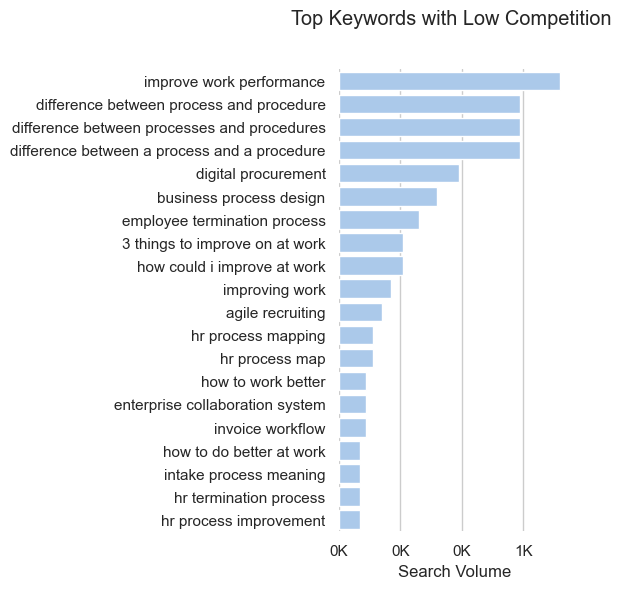

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(3, 6))

f.suptitle("Top Keywords with Low Competition")
sns.set_color_codes("pastel")
sns.barplot(x="search_volume", y="keyword",
            data=df_ck.query("competition_level == 'LOW'").sort_values(by="search_volume", ascending=False).head(20), color="b")

ax.set(ylabel="",
       xlabel="Search Volume")

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))
plt.legend([],[], frameon=False)
sns.despine(left=True, bottom=True)

In [ ]:
plt.figure(figsize=(4,3))
sns.boxplot(data=df_ck, x="cpc", y="main_intent")
plt.title("Box Plot of CPC")
plt.xlabel("CPC")
plt.show()

<div class="markdown-google-sans">

#### Save Competitor Keywords in Google Sheet
</div>

Create a worksheet in the spreadsheet

In [ ]:
worksheets = [sheet.title for sheet in spreadsheet.worksheets()]

if not filename_ck in worksheets:
  print("Create a new worksheet")
  worksheet_ck = spreadsheet.add_worksheet(title=filename_ck, rows=100, cols=30)
else:
  print("Attach to existing worksheet")
  worksheet_ck = spreadsheet.worksheet(title=filename_ck)

Store the dataframe in the worksheet

In [ ]:
worksheet_ck.clear()

In [ ]:
worksheet_ck.update([df_ck.columns.values.tolist()] + df_ck.fillna('').values.tolist())

<div class="markdown-google-sans">

### Find your content gaps
</div>

[This endpoint](https://docs.dataforseo.com/v3/dataforseo_labs/google/domain_intersection/live/?python) reveals keywords where specified domains rank within the same SERP. You get search volume, competition, CPC, and impressions data for each intersecting keyword, plus SERP element data for both domains.

If you set intersections to false, you will get keywords for which the domain specified as target1 has results in SERP and the domain specified as target2 doesn’t.

For example below, I want to see what my website [amigocci.io](https://amigocci.io) is missing compared to one of my competitor.

In [68]:
post_data_cg = dict()
post_data_cg[len(post_data_cg)] = dict(
    
    target1="www.pipefy.com	",
    target2="ibm.com",
    location_name="United States",
    language_name="English",
    limit=50,
    intersections=False
)

In [69]:
import json

filename_cg = "domain_intersection"
file_path = f'{filename_cg}.json'

if os.path.isfile(file_path):
  print('Loading existing file')
  with open(file_path, "r") as f:
    response_cg = json.load(f)
else:
  print('Get data from DataForSEO')
  response_cg = seodata_client.post(
      "/v3/dataforseo_labs/google/domain_intersection/live", post_data_cg
  )

  if response_cg["status_code"] == 20000:
    with open(file_path, "w") as f:
      json.dump(response_cg, f)
  else:
    print(
        "error. Code: %d Message: %s"
            % (response_cg["status_code"], response_cg["status_message"])
        )

Get data from DataForSEO


<div class="markdown-google-sans">

#### Content Gap Response
</div>

In [ ]:
response_cg['cost']

In [70]:
items_cg = response_cg['tasks'][0]['result'][0]['items']

In [71]:
import pandas as pd

data_cg = {
    "keyword": [],
    "competition": [],
    "competition_level": [],
    "cpc": [],
    "search_volume": [],
    "low_top_of_page_bid": [],
    "high_top_of_page_bid": [],
    "backlinks": [],
    "dofollow": [],
    "referring_pages": [],
    "referring_domains": [],
    "referring_main_domains": [],
    "rank": [],
    "main_domain_rank": [],
    "main_intent": [],
}

for item in items_cg:

    data_cg["keyword"].append(item['keyword_data']['keyword'])
    data_cg["competition"].append(item['keyword_data']['keyword_info']['competition'])
    data_cg["competition_level"].append(item['keyword_data']['keyword_info']['competition_level'])
    
    data_cg["cpc"].append(item['keyword_data']['keyword_info']['cpc'])
    data_cg["search_volume"].append(item['keyword_data']['keyword_info']['search_volume'])
    data_cg["low_top_of_page_bid"].append(item['keyword_data']['keyword_info']['low_top_of_page_bid'])
    data_cg["high_top_of_page_bid"].append(item['keyword_data']['keyword_info']['high_top_of_page_bid'])
    
    data_cg["backlinks"].append(item['keyword_data']['avg_backlinks_info']['backlinks'])
    data_cg["dofollow"].append(item['keyword_data']['avg_backlinks_info']['dofollow'])
    data_cg["referring_pages"].append(item['keyword_data']['avg_backlinks_info']['referring_pages'])
    data_cg["referring_domains"].append(item['keyword_data']['avg_backlinks_info']['referring_domains'])
    
    data_cg["referring_main_domains"].append(item['keyword_data']['avg_backlinks_info']['referring_main_domains'])
    data_cg["rank"].append(item['keyword_data']['avg_backlinks_info']['rank'])
    data_cg["main_domain_rank"].append(item['keyword_data']['avg_backlinks_info']['main_domain_rank'])
    data_cg["main_intent"].append(item['keyword_data']['search_intent_info']['main_intent'])

df_cg = pd.DataFrame(data_cg)

<div class="markdown-google-sans">

#### Filter Content Gap Response
</div>

In [72]:
df_cg.query("competition_level == 'LOW' & cpc == cpc").sort_values(by="search_volume", ascending=False).head(5)

,keyword,competition,competition_level,cpc,search_volume,low_top_of_page_bid,high_top_of_page_bid,backlinks,dofollow,referring_pages,referring_domains,referring_main_domains,rank,main_domain_rank,main_intent
0,purchase orders,NaN,LOW,10.10,550000,0.02,16.219999,353.600006,198.100006,312.000000,58.000000,50.200001,106.199997,521.500000,transactional
1,reimb,NaN,LOW,6.54,135000,2.28,7.210000,211.100006,120.500000,198.199997,68.099998,63.099998,165.899994,608.599976,informational
2,procedure,NaN,LOW,0.18,74000,NaN,NaN,204.300003,153.000000,198.899994,122.099998,116.000000,237.600006,667.799988,informational
3,procedures,NaN,LOW,0.18,74000,NaN,NaN,183.699997,136.300003,178.600006,106.500000,101.000000,228.899994,734.000000,informational
4,operational planning team,NaN,LOW,2.73,49500,1.17,4.230000,16.100000,8.400000,15.000000,10.400000,10.000000,42.200001,452.500000,informational


<div class="markdown-google-sans">

#### Plot Content Gap Keywords
</div>

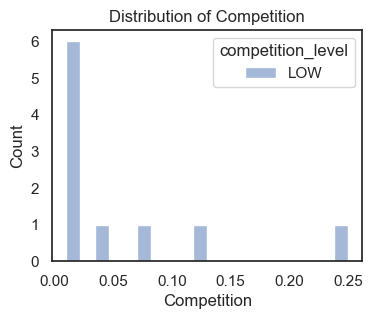

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('white')

plt.figure(figsize=(4,3))
sns.histplot(data=df_cg, x="competition", hue='competition_level', bins=20, kde=False)
plt.title("Distribution of Competition")
plt.xlabel("Competition")
plt.ylabel("Count")
plt.show()

In [ ]:
plt.figure(figsize=(4,3))
sns.boxplot(data=df_cg, x="cpc", y="main_intent")
plt.title("Box Plot of CPC")
plt.xlabel("CPC")
plt.show()

<div class="markdown-google-sans">

#### Save Content Gap in Google Sheet
</div>

Create a worksheet in the spreadsheet

In [ ]:
worksheets = [sheet.title for sheet in spreadsheet.worksheets()]
if not filename_cg in worksheets:
  print("Create a new worksheet")
  worksheet_cg = spreadsheet.add_worksheet(title=filename_cg, rows=100, cols=30)
else:
  print("Attach to existing worksheet")
  worksheet_cg = spreadsheet.worksheet(title=filename_cg)

Store the dataframe in the worksheet

In [ ]:
worksheet_cg.clear()

In [ ]:
worksheet_cg.update([df_cg.columns.values.tolist()] + df_cg.fillna('').values.tolist())

<div class="markdown-google-sans">

### Learn how much traffic your competitors get
</div>

[This endpoint](https://docs.dataforseo.com/v3/dataforseo_labs/google/bulk_traffic_estimation/live/?python) gives you estimated monthly traffic volumes for up to 1,000 domains, including organic, paid search, featured snippet, and local pack results.

In [ ]:
top_competitors['main_domain'].to_list()

In [88]:
post_data_ct = dict()
post_data_ct[len(post_data_ct)] = dict(
    targets=[
      'techtarget.com',
 'ibm.com',
 'salesforce.com',
 'pipefy.com',
 'blog.hubspot.com',
 'kissflow.com',
 'atlassian.com',
 'investopedia.com',
 'laserfiche.com',
 'centricconsulting.com'
    ],
    location_name="United States",
    language_name="English",
    item_types=[
        "organic",
        "paid"
    ]
)

In [ ]:
import json

filename_ct = "bulk_traffic_estimation"
file_path = f'{filename_ct}.json'

if os.path.isfile(file_path):
  print('Loading existing file')
  with open(file_path, "r") as f:
    response_ct = json.load(f)
else:
  print('Get data from DataForSEO')
  response_ct = seodata_client.post(
      "/v3/dataforseo_labs/google/bulk_traffic_estimation/live", post_data_ct
  )

  if response_ct["status_code"] == 20000:
    with open(file_path, "w") as f:
      json.dump(response_ct, f)
  else:
    print(
        "error. Code: %d Message: %s"
            % (response_ct["status_code"], response_ct["status_message"])
        )

In [ ]:
response_ct['cost']

In [96]:
items_ct = response_ct['tasks'][0]['result'][0]['items']

In [99]:
import pandas as pd

data_ct = {
    "target": [],
    "organic_etv": [],
    "organic_count": [],
    "paid_etv": [],
    "paid_count": []
}

for item in items_ct:
    data_ct["target"].append(item['target'])
    data_ct["organic_etv"].append(item['metrics']['organic']['etv'])
    data_ct["organic_count"].append(item['metrics']['organic']['count'])
    data_ct["paid_etv"].append(item['metrics']['paid']['etv'])
    data_ct["paid_count"].append(item['metrics']['paid']['count'])

df_ct = pd.DataFrame(data_ct)

In [ ]:
df_ct

<div class="markdown-google-sans">

#### Filter Competitor Traffic Response
</div>

In [ ]:
df_ct.query("target != 'en.wikipedia.org'").sort_values(by="organic_etv", ascending=False)

<div class="markdown-google-sans">

#### Plot Competitor Traffic
</div>

In [102]:
df_ct['total_etv'] = df_ct['organic_etv'] + df_ct['paid_etv']

NameError: name 'df_ct' is not defined

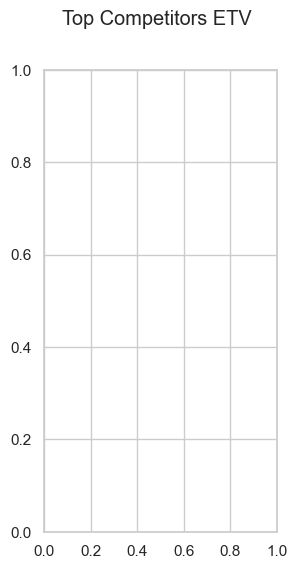

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(3, 6))

f.suptitle("Top Competitors ETV")

sns.set_color_codes("pastel")
sns.barplot(x="total_etv", y="target",
            data=df_ct.query("target != 'en.wikipedia.org'").sort_values(by="total_etv", ascending=False),
            label="Total", color="b")

sns.set_color_codes("muted")
sns.barplot(x="paid_etv", y="target",
            data=df_ct.query("target != 'en.wikipedia.org'").sort_values(by="total_etv", ascending=False),
            label="Paid", color="b")

ax.legend(ncol=2, loc="lower right", frameon=True)
ax.set(ylabel="",
       xlabel="ETV")

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{x/10**6:.0f}M'))
sns.despine(left=True, bottom=True)

<div class="markdown-google-sans">

#### Save Competitor Traffic in Google Sheet
</div>

Create a worksheet in the spreadsheet

In [ ]:
worksheets = [sheet.title for sheet in spreadsheet.worksheets()]
if not filename_ct in worksheets:
  print("Create a new worksheet")
  worksheet_ct = spreadsheet.add_worksheet(title=filename_ct, rows=100, cols=30)
else:
  print("Attach to existing worksheet")
  worksheet_ct = spreadsheet.worksheet(title=filename_ct)

Store the dataframe in the worksheet

In [ ]:
worksheet_ct.clear()

In [ ]:
worksheet_ct.update([df_ct.columns.values.tolist()] + df_ct.fillna('').values.tolist())

<div class="markdown-google-sans">

## Organic Google bulk SERP
</div>


[This endpoint](https://docs.dataforseo.com/v3/serp/google/organic/overview/?python) gives you search results specific to the keyword, search engine, and location parameters you set.


In [ ]:
# Related keywords
related_keywords = df_ki.query("competition_level == 'LOW' & keyword_difficulty < 50").sort_values(by="cpc", ascending=False)['keywords'].to_list()
print(f"There are {len(related_keywords)} related keywords")

In [ ]:
# Googlee Ads keywords
google_ads_keywords = df_ga.query("competition == 'LOW'").sort_values(by="search_volume", ascending=False)['keywords'].to_list()
print(f"There are {len(google_ads_keywords)} Google Ads keywords")

In [ ]:
# combine the two list of keywords
keywords_serp = related_keywords + google_ads_keywords

# remove duplicates
keywords_serp = list(dict.fromkeys(keywords_serp))

print(f"There are {len(keywords_serp)} unique keywords for the SERP analysis")

You can send up to 2000 API calls per minute, with each POST call containing no more than 100 tasks. If your POST call contains over 100 tasks, the tasks over this limit will return the 40006 error.

In [107]:
post_data_bs = dict()
for keyword in keywords_serp[:100]:
  post_data_bs[len(post_data_bs)] = dict(
      location_name="United States",
      language_name="English",
      keyword=keyword,
      depth=10
  )

In [ ]:
import json

filename_bs = "bulk_google_serp"
file_path =  f'{filename_bs}.json'

if os.path.isfile(file_path):
  print('Loading existing file')
  with open(file_path, "r") as f:
    response_bs = json.load(f)
else:
  print('Post tasks to DataForSEO')
  response_bs = seodata_client.post("/v3/serp/google/organic/task_post", post_data_bs)
  if response_bs["status_code"] == 20000:
    with open(file_path, "w") as f:
      json.dump(response_bs, f)
  else:
    print(
      "error. Code: %d Message: %s"
          % (response_bs["status_code"], response_bs["status_message"])
      )

The cost can be found from the POST request

In [ ]:
response_bs['cost']

Get the results from DataForSEO servers and save Google Drive in the response folder.

You might need to run this cell twice if DataForSEO didn't process the 100 tasks posted earlier

In [ ]:
from tqdm.notebook import tqdm

response_ready = seodata_client.get("/v3/serp/google/organic/tasks_ready")

if response_ready['status_code'] == 20000:
    for task in response_ready['tasks']:
        if (task['result'] and (len(task['result']) > 0)):
            for resultTaskInfo in tqdm(task['result']):
                if(resultTaskInfo['endpoint_regular']):
                    result_bs = seodata_client.get(resultTaskInfo['endpoint_regular'])
                    result_keyword = result_bs["tasks"][0]['result'][0]["keyword"].replace(" ", "_")
                    file_path_keyword = os.path.join(RESPONSE_FOLDER_PATH, f'{filename_bs}_{result_keyword}.json')
                    with open(file_path_keyword, "w") as f:
                      json.dump(result_bs, f)
else:
    print("error. Code: %d Message: %s" % (response_ready["status_code"], response_ready["status_message"]))

Load the result from Drive

In [118]:
import os
import json

results_bs = []

ANALYSIS_FOLDER= 'analysis'
# Get a list of all files in the current directory
files = os.listdir(ANALYSIS_FOLDER)

# Loop through each file
for file in files:
    # Check if the file starts with "bulk_google_serp_" and ends with ".json"
    if file.startswith(f'{filename_bs}_') and file.endswith(".json"):
        # Open the file and load its contents as JSON
        with open(os.path.join(ANALYSIS_FOLDER, file)) as f:
            data = json.load(f)
        # Append the JSON data to the result list
        results_bs.append(data)

In [ ]:
import pandas as pd

# results_bs[0]["tasks"][0]['result'][0]['keyword']
# results_bs[0]["tasks"][0]['result'][0]['items'][0]

data_bs = {
    "keyword": [],
    "type": [],
    "rank_group": [],
    "rank_absolute": [],
    "domain": [],
    "title": [],
    "description": [],
    "url": [],
    "breadcrumb": []
}

for result in results_bs:
    keyword = result["tasks"][0]['result'][0]['keyword']
    items = result["tasks"][0]['result'][0]['items']
    for item in items:
      data_bs['keyword'].append(keyword)
      data_bs['type'].append(item['type'])
      data_bs['rank_group'].append(item['rank_group'])
      data_bs['rank_absolute'].append(item['rank_absolute'])
      data_bs['domain'].append(item['domain'])
      data_bs['title'].append(item['title'])
      data_bs['description'].append(item['description'])
      data_bs['url'].append(item['url'])
      data_bs['breadcrumb'].append(item['breadcrumb'])

df_bs = pd.DataFrame(data_bs)

df_bs[['title', 'description']] = df_bs[['title', 'description']].fillna('')

df_bs

<div class="markdown-google-sans">

#### Filter Google Bulk SERP
</div>

In [ ]:
df_bs.query("rank_absolute < 3")

<div class="markdown-google-sans">

#### Get the search intent for each keyword
</div>

[This endpoint](https://docs.dataforseo.com/v3/dataforseo_labs/google/search_intent/live/?python) provides search intent data for up to 1,000 keywords

In [ ]:
post_data_si = dict()
post_data_si[len(post_data_si)] = dict(
    keywords=keywords_serp[:100],
    language_name="English"
)

In [ ]:
import json

filename_si = "search_intent"
file_path = os.path.join(RESPONSE_FOLDER_PATH, f'{filename_si}.json')

if os.path.isfile(file_path):
  print('Loading existing file')
  with open(file_path, "r") as f:
    response_si = json.load(f)
else:
  print('Get data from DataForSEO')
  response_si = seodata_client.post(
      "/v3/dataforseo_labs/google/search_intent/live", post_data_si
  )

  if response_si["status_code"] == 20000:
    with open(file_path, "w") as f:
      json.dump(response_si, f)
  else:
    print(
        "error. Code: %d Message: %s"
            % (response_si["status_code"], response_si["status_message"])
        )

Get the cost

In [ ]:
response_si['tasks'][0]['cost']

Create a dictionnary with the search intent for each keyword

In [ ]:
items_si = response_si['tasks'][0]['result'][0]['items']
search_intents = {item['keyword']: item['keyword_intent']['label'] for item in items_si}

Save the result in the dataframe

In [ ]:
df_bs['search_intent'] = df_bs.apply(lambda row: search_intents.get(row['keyword'], float('nan')), axis=1)

<div class="markdown-google-sans">

#### Get the search volume and CPC each keyword
</div>

[This endpoint](https://docs.dataforseo.com/v3/dataforseo_labs/google/historical_search_volume/live/?python) provide Google historical search volume, current cost-per-click, and competition values for paid search, as well as current impressions and SERP

In [ ]:
post_data_sv = dict()
post_data_sv[len(post_data_sv)] = dict(
    keywords=keywords_serp[:100],
    location_name="United States",
    language_name="English"
)

In [ ]:
import json

filename_sv = "search_volume"
file_path = os.path.join(RESPONSE_FOLDER_PATH, f'{filename_sv}.json')

if os.path.isfile(file_path):
  print('Loading existing file')
  with open(file_path, "r") as f:
    response_sv = json.load(f)
else:
  print('Get data from DataForSEO')
  response_sv = seodata_client.post(
      "/v3/dataforseo_labs/google/historical_search_volume/live", post_data_sv
  )

  if response_sv["status_code"] == 20000:
    with open(file_path, "w") as f:
      json.dump(response_sv, f)
  else:
    print(
        "error. Code: %d Message: %s"
            % (response_sv["status_code"], response_sv["status_message"])
        )

Get the cost

In [ ]:
response_sv['tasks'][0]['cost']

Create dictionnaries with the results for each keyword

In [ ]:
items_sv = response_sv['tasks'][0]['result'][0]['items']
competition_levels = { item['keyword']: item['keyword_info']['competition_level'] for item in items_sv }
cost_per_clicks = { item['keyword']: item['keyword_info']['cpc'] for item in items_sv}
search_volumes = { item['keyword']: item['keyword_info']['search_volume'] for item in items_sv}

Save the result in the dataframe

In [ ]:
df_bs['competition_level'] = df_bs.apply(lambda row: competition_levels.get(row['keyword'], float('nan')), axis=1)
df_bs['cpc'] = df_bs.apply(lambda row: cost_per_clicks.get(row['keyword'], float('nan')), axis=1)
df_bs['search_volume'] = df_bs.apply(lambda row: search_volumes.get(row['keyword'], float('nan')), axis=1)

<div class="markdown-google-sans">

#### Save Google Bulk SERP
</div>

Create a worksheet in the spreadsheet

In [ ]:
worksheets = [sheet.title for sheet in spreadsheet.worksheets()]
if not filename_bs in worksheets:
  print("Create a new worksheet")
  worksheet_bs = spreadsheet.add_worksheet(title=filename_bs, rows=100, cols=20)
else:
  print("Attach to existing worksheet")
  worksheet_bs = spreadsheet.worksheet(title=filename_bs)

Store the dataframe in the worksheet

In [ ]:
worksheet_bs.clear()

In [ ]:
worksheet_bs.update([df_bs.columns.values.tolist()] + df_bs.fillna('').values.tolist())

<div class="markdown-google-sans">

## SERP Relevance
</div>

<div class="markdown-google-sans">

### Compute relevance of title and meta description with the keyword
</div>

Classify the relevance of SERP results based on the title, meta description, keyword, and search intent.

Open the worksheet bulk_google_serp

In [ ]:
filename_bs = "bulk_google_serp"

worksheets = [sheet.title for sheet in spreadsheet.worksheets()]
if not filename_bs in worksheets:
  print("Create a new worksheet")
  worksheet_bs = spreadsheet.add_worksheet(title=filename_bs, rows=100, cols=20)
else:
  print("Attach to existing worksheet")
  worksheet_bs = spreadsheet.worksheet(title=filename_bs)

Open a JSON file or create a new dictionnary

In [ ]:
import json

filename_sr = "serp_relevance"
file_path_sr = os.path.join(RESPONSE_FOLDER_PATH, f'{filename_sr}.json')

if os.path.isfile(file_path_sr):
  print('Loading existing file')
  with open(file_path_sr, "r") as f:
    serp_relevance = json.load(f)
else:
  print('Create a new dictionary')
  serp_relevance = dict()

Create a new column in Google Sheet

In [ ]:
columns = worksheet_bs.row_values(1)
if filename_sr not in columns:
  print("create a new column")
  worksheet_bs.add_cols(1)
  worksheet_bs.update_cell(1, len(columns) + 1, filename_sr)
else:
  print("Column already exist")

Use a sentence transformer [all-MiniLM-L6-v2](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2)

In [ ]:
!pip install sentence-transformers --quiet

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

def get_relevance(keyword, title, description):
  embeddings = model.encode([keyword, title, description])
  keyword_embedding = embeddings[0]
  title_embedding = embeddings[1]
  description_embedding = embeddings[2]

  similarity_title = cosine_similarity([keyword_embedding], [title_embedding])[0][0]
  similarity_description = cosine_similarity([keyword_embedding], [description_embedding])[0][0]

  average_similarity = (similarity_title + similarity_description) / 2

  return average_similarity

In [ ]:
get_relevance("panda", "bird", "wings")

In [ ]:
get_relevance("fly", "bird", "wings")

In [ ]:
from tqdm.notebook import tqdm
tqdm.pandas()
df_bs['relevance'] = df_bs.progress_apply(lambda row: get_relevance(row['keyword'], row['title'], row['description']), axis=1)

<div class="markdown-google-sans">

#### Save Google Bulk SERP
</div>

Create a worksheet in the spreadsheet

In [ ]:
worksheets = [sheet.title for sheet in spreadsheet.worksheets()]
if not filename_bs in worksheets:
  print("Create a new worksheet")
  worksheet_bs = spreadsheet.add_worksheet(title=filename_bs, rows=100, cols=20)
else:
  print("Attach to existing worksheet")
  worksheet_bs = spreadsheet.worksheet(title=filename_bs)

Store the dataframe in the worksheet

In [ ]:
worksheet_bs.clear()

In [ ]:
worksheet_bs.update([df_bs.columns.values.tolist()] + df_bs.fillna('').values.tolist())

<div class="markdown-google-sans">

### Create the Relevance Graph
</div>

In [ ]:
!pip install pyecharts --quiet
!pip install plotly --quiet

from pyecharts.charts import Graph
import pyecharts.options as opts
from pyecharts.globals import ThemeType

Create the similarity matrix with cosine distance between embeddings

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def get_similarity_matrix(keywords):
    keyword_embeddings = model.encode(keywords)
    similarity_matrix = cosine_similarity(keyword_embeddings)
    df_similarity = pd.DataFrame(similarity_matrix, columns=keywords, index=keywords)
    return df_similarity

get_similarity_matrix(["fly", "bird", "wings"])

In [ ]:
relevance_matrix = get_similarity_matrix(keywords_serp[:100])

We define 2 types of nodes:
- keyword (search queries)
- SERP (search result)

In [ ]:
categories = [
    dict(name="Informational"),
    dict(name="Navigational"),
    dict(name="Transactional"),
    dict(name="Commercial"),
    dict(name="SERP"),
]

Define the keywords nodes

In [ ]:
import numpy as np

min_volume = df_bs['search_volume'].min()
max_volume = df_bs['search_volume'].max()
node_names = relevance_matrix.index.to_list()
nodes = []
for index, node_name in enumerate(node_names):
  search_volume = df_bs.loc[df_bs['keyword'] == node_name,
                            'search_volume'].fillna(0).iloc[0]
  search_volume_norm = 50 + (search_volume - min_volume) * 80 / (max_volume - min_volume)
  if np.isnan(search_volume_norm):
    search_volume_norm = 1

  search_intent = df_bs.loc[df_bs['keyword'] == node_name,
                            'search_intent'].iloc[0]
  if search_intent.startswith("informational"):
      category_id = 0
  elif search_intent.startswith("navigational"):
      category_id = 1
  elif search_intent.startswith("transactional"):
      category_id = 2
  elif search_intent.startswith("commercial"):
      category_id = 3

  node = dict(
      id=index,
      name=node_name,
      value=search_volume,
      symbolSize=search_volume_norm,
      category=category_id,
      label=dict(show=True),
  )
  nodes.append(node)

last_index = index

Define the edges between the keywords and the SERP results

In [ ]:
import numpy as np

threshold = 0.8
edges = []
for index_outer, node_name_outer in enumerate(node_names):
    for index_inner, node_name_inner in enumerate(node_names[0:index_outer]):
        edge_value = relevance_matrix[node_name_inner][node_name_outer]

        if np.isnan(edge_value):
            continue
        if edge_value <= threshold:
            continue

        edge = dict(
            source=index_outer,
            target=index_inner,
            value=float(edge_value),
            lineStyle=opts.LineStyleOpts(color='blue', width=1.0, opacity=0.1),
            label=dict(show=False),
        )
        edges.append(edge)

Define the SERP result nodes and edges

In [ ]:
for index, row in df_bs.iterrows():
  node_id = last_index + 1 + index,
  node = dict(
      id= node_id,
      name=row['domain'],
      symbolSize= 15 - row['rank_group'],
      value= row['rank_group'],
      category=4,
      label=dict(show=False),
  )
  nodes.append(node)

  keyword = row['keyword']
  relevance = row['relevance']
  edge = dict(
      source=node_names.index(keyword),
      target=node_id,
      value=relevance,
      lineStyle=opts.LineStyleOpts(color='black', width=0.5, opacity=0.3),
      label=dict(show=False),
  )
  edges.append(edge)

Plot the graph

In [ ]:
(
    Graph(init_opts=opts.InitOpts(theme=ThemeType.WHITE, width="60vw", height="80vh", is_horizontal_center=True)) #  width="1200px", height="800px"
    .add(
        series_name="",
        edge_length=[30, 60], # this is the edge length range that the force layout works with
        nodes=nodes,
        links=edges,
        categories=categories,
        layout='force',
        repulsion=80,
        friction=0.6,
        label_opts=opts.LabelOpts(is_show=True),
        is_focusnode=True,
        is_roam=True, # zoom in and out with the mouse
        is_draggable=True, # drag the nodes with the mouse
    )
    #.set_global_opts(title_opts=opts.TitleOpts(title="SERP Analysis"))
    .render("relevance_graph.html")
)


<div class="markdown-google-sans">

## GPT Classification
</div>

<div class="markdown-google-sans">

### Site Categories
</div>


Thanks to @[DannyRichman](https://twitter.com/DannyRichman?ref_src=twsrc%5Egoogle%7Ctwcamp%5Eserp%7Ctwgr%5Eauthor) to provide the follwoing prompt with examples:

```
Classify the website domain in one of the following categories - technology, news, reviews, wiki, courses/learning, Social Media, or other, based on the type of information published on it.

- Keyword: aws.amazon.com, Classification: Technology
- Keyword: en.wikipedia.org, Classification: Wiki
- Keyword: www.coursera.org, Classification: Courses/Learning
- Keyword: www.gartner.com, Classification: Reviews
- Keyword: www.linkedin.com, Classification: Social Media
- Keyword: edition.cnn.com, Classification: news
- Keyword: hubspot.com, Classification: Digital Marketing
- Keyword: seo.ai, Classification: SEO
- Keyword: www.thisiscolossal.com, Classification: Other
```

Install openai and define prompt

In [ ]:
!pip install openai --quiet
import openai
openai.api_key = openai_api_key

In [ ]:
def get_category(text):
  if len(text.strip()) < 5:
    return

  prompt = f"Classify \
  the website domain in one of the following categories - \
  technology, news, reviews, wiki, courses/learning, Social Media, or other,\
  based on the type of information published on it.\n\
  Keyword: aws.amazon.com, Classification: Technology\n\
  Keyword: en.wikipedia.org, Classification: Wiki\n\
  Keyword: www.coursera.org, Classification: Courses/Learning\n\
  Keyword: www.gartner.com, Classification: Reviews\n\
  Keyword: www.linkedin.com, Classification: Social Media\n\
  Keyword: edition.cnn.com, Classification: news\n\
  Keyword: hubspot.com, Classification: Digital Marketing\n\
  Keyword: seo.ai, Classification: SEO\n\
  Keyword: alliai.com, Classification: SEO\n\
  Keyword: www.thisiscolossal.com, Classification: Other\n\n\
  From the given examples, classify the keyword '{text}', Classification:"

  response = openai.Completion.create(
      engine="text-davinci-003",
      prompt=prompt,
      temperature=0,
      max_tokens=64,
      top_p=1,
      frequency_penalty=0,
      presence_penalty=0,
      stop=["\n"]
  )

  return response.choices[0].text.strip()

Test the API

In [ ]:
get_category("seo.ai")

Open worsheet "bulk_google_serp"

In [ ]:
filename_bs = "bulk_google_serp"

worksheets = [sheet.title for sheet in spreadsheet.worksheets()]
if not filename_bs in worksheets:
  print("Create a new worksheet")
  worksheet_bs = spreadsheet.add_worksheet(title=filename_bs, rows=100, cols=20)
else:
  print("Attach to existing worksheet")
  worksheet_bs = spreadsheet.worksheet(title=filename_bs)

Open a Json file called "category" or create a new dictionary

In [ ]:
import json

filename_ca = "domain_category"
file_path_ca = os.path.join(RESPONSE_FOLDER_PATH, f'{filename_ca}.json')

if os.path.isfile(file_path_ca):
  print('Loading existing file')
  with open(file_path_ca, "r") as f:
    domain_category = json.load(f)
else:
  print('Create a new dictionary')
  domain_category = dict()

Check and create "title_intent" column if it doesn't exist

In [ ]:
columns = worksheet_bs.row_values(1)
if filename_ca not in columns:
  print("create a new column")
  worksheet_bs.add_cols(1)
  worksheet_bs.update_cell(1, len(columns) + 1, filename_ca)
else:
  print("Column already exist")

Find the category of each website and save in spreadsheet

In [ ]:
from tqdm.notebook import tqdm

domain_column = worksheet_bs.find('domain', in_row=1).col
domain_rows = worksheet_bs.col_values(domain_column)
category_column = worksheet_bs.find(filename_ca, in_row=1).col
category_rows = worksheet_bs.col_values(category_column)


if False: # can be a costly process, only set to True when ready
  quota_count = 0 # quota to update the spreadsheet
  for row, website in tqdm(enumerate(domain_rows[1:], start=2),
                          desc='Update categories',
                          total=len(domain_rows)-1):
    #if row < 1200: # in case we need to skip some rows
    #  continue
    if not website in domain_category:
      category = get_category(website)
      if category is None:
        domain_category[website] = ""
      else:
        domain_category[website] = get_category(website)

    worksheet_bs.update_cell(row, category_column, domain_category[website])

    quota_count += 1
    if quota_count >= 500:
      time.sleep(60)  # Wait for 60 seconds
      quota_count = 0  # Reset quota counter

  with open(file_path_ca, "w") as f:
    json.dump(domain_category, f)

<div class="markdown-google-sans">

## Google Cloud
</div>

<div class="markdown-google-sans">

### Entity analysis
</div>


In [ ]:
from google.cloud import language_v1

def get_entities(text):
    # Instantiates a client
    google_client = language_v1.LanguageServiceClient(
        client_options=
        {
            "api_key": google_api_key,
            "quota_project_id": google_project_id
        }
    )

    # Available types: PLAIN_TEXT, HTML
    type_ = language_v1.Document.Type.PLAIN_TEXT
    encoding_type = language_v1.EncodingType.UTF8
    language = "en"

    # Prepare the payload
    document = {"content": text, "type": type_, "language": language}

    # Make the API request
    response = google_client.analyze_entities(
        request={"document": document, "encoding_type": encoding_type}
    )

    entities = [
        {
            'name': entity.name,
            'type': language_v1.Entity.Type(entity.type_).name,
            'salience': entity.salience,
            'number_mention': len(entity.mentions)
        } for entity in response.entities
    ]

    return entities

Automatically extract entities on titles and meta descriptions

In [ ]:
import json
import time
from tqdm.notebook import tqdm

filename_et = "entities"
file_path = os.path.join(RESPONSE_FOLDER_PATH, f'{filename_et}.json')

if os.path.isfile(file_path):
  print('Loading existing file')
  with open(file_path, "r") as f:
    entities = json.load(f)
else:
  print('Get data from Google API')
  texts = df_bs[['title', 'description']].agg(': '.join, axis=1).tolist()

  entities = []
  quota_count = 0
  for text in tqdm(texts, desc='Processing texts'):
    # default quota is 600 per minute
    quota_count += 1
    if quota_count >= 600:
      time.sleep(60)  # Wait for 60 seconds
      quota_count = 0  # Reset quota counter

    text_entities = get_entities(text)
    entities.append(text_entities)

  with open(file_path, "w") as f:
    json.dump(entities, f)

In [ ]:
# Create a new DataFrame with the entities array
df_et = pd.DataFrame({'entities': entities})

# Combine the original DataFrame (selecting specific columns) with the new entities DataFrame
# Make sure to reset the index for proper alignment
df_et = pd.concat([df_bs[['keyword', 'url', 'title', 'description']].reset_index(drop=True), df_et], axis=1)

# Explode the 'entities' column, creating a new row for each element in the 'entities' column
# Duplicate the values from other columns for each new row
# Reset the index to reindex the new DataFrame
df_et = df_et.explode('entities').reset_index(drop=True)

# Split the dictionaries in the 'entities' column into separate columns
# Convert the dictionaries into a DataFrame and concatenate with the existing DataFrame
df_et = pd.concat([df_et, df_et['entities'].apply(pd.Series)], axis=1)

# Drop the original 'entities' column as it is no longer needed
df_et = df_et.drop('entities', axis=1)

In [ ]:
df_et.head(5)

<div class="markdown-google-sans">

#### Save Entities in Google Sheet
</div>

Create a worksheet in the spreadsheet

In [ ]:
worksheets = [sheet.title for sheet in spreadsheet.worksheets()]
if not filename_et in worksheets:
  print("Create a new worksheet")
  worksheet_et = spreadsheet.add_worksheet(title=filename_et, rows=100, cols=30)
else:
  print("Attach to existing worksheet")
  worksheet_et = spreadsheet.worksheet(title=filename_et)

Store the dataframe in the worksheet

In [ ]:
worksheet_et.clear()

In [ ]:
worksheet_et.update([df_et.columns.values.tolist()] + df_et.fillna('').values.tolist())


<div class="markdown-google-sans">

### Google Knowledge Graph (comming soon)
</div>

When you're doing keyword research, it's important to think about whether it makes sense to focus on a specific keyword if there's already a popular source for it. I mean, Google wants to give people the best info when they search, right? And with more and more zero-click searches happening, there's more competition for search terms and getting featured in search results too.